In [3]:
!pwd!pwd
import sys
import types

# Import the real anchored_artists module
import mpl_toolkits.axes_grid1.anchored_artists as anchored_artists

# If AnchoredEllipse doesn't exist, define a dummy version
if not hasattr(anchored_artists, "AnchoredEllipse"):
    print("AnchoredEllipse not found – faking it to avoid import errors.")

    class AnchoredEllipse:
        def __init__(*args, **kwargs):
            raise NotImplementedError("AnchoredEllipse is not implemented – skipping.")

    anchored_artists.AnchoredEllipse = AnchoredEllipse

/bin/bash: pwd!pwd: command not found
AnchoredEllipse not found – faking it to avoid import errors.


In [4]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%matplotlib inline
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from ipywidgets import interactive, FloatSlider, interact, fixed
from divtel import *
import copy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroplan.plots import plot_sky
from astroplan import FixedTarget
#from . import utils
#from .const import COLORS
#from . import pointing

from matplotlib.transforms import Affine2D
from astropy.visualization.wcsaxes import SphericalCircle

import healpy as hp
import tqdm

#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## LOAD CTA CONFIG

In [5]:
cta = CTA_Info('south')

Observer         :  CTA South
Location         :  Paranal , (1946.635798, -5467.63394562, -2642.49852123) km
Observation time :  2025-08-18T09:06:16.977


In [6]:
# Note that if the radius is in meters, 
# you can set LoadConfig(file, radius="meters")
# defalut is in degrees

array = LoadConfig("/Users/macbook/divtel/Paranal_only_SST.txt", frame=cta)


## Check configuration table

In [7]:
array.table.units = "deg"
array.table


id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,199.0,0.0,16.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,200.19
2,-230.0,0.0,22.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,229.36
3,-249.0,-325.0,40.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.12
4,-249.0,325.0,17.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.16
5,-249.0,-577.0,54.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.62
6,-249.0,577.0,8.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.51
7,-220.0,-797.0,68.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,827.51
8,-220.0,797.0,10.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,826.84


In [8]:
table=array.table

## Check the telescope spatial distribution
This is useful to pick the groups

In [9]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,199.0,0.0,16.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,200.19
2,-230.0,0.0,22.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,229.36
3,-249.0,-325.0,40.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.12
4,-249.0,325.0,17.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.16
5,-249.0,-577.0,54.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.62
6,-249.0,577.0,8.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.51
7,-220.0,-797.0,68.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,827.51
8,-220.0,797.0,10.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,826.84


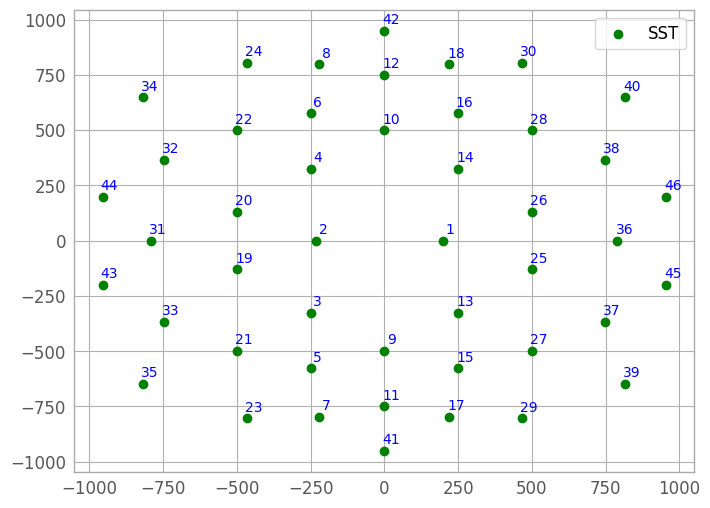

In [10]:
# Loop through all the telescopes
#for fov in array.table["fov"]:
#    print(fov)
colors = [
    'lightseagreen' if np.isclose(fov, 14.5356) else
    'blueviolet' if np.isclose(fov, 46.707) else 
    'green' if np.isclose(fov, 62.462) else
    'red'  # Default color if none of the conditions match
    for fov in array.table["fov"]
]
fov_labels = {
    'lightseagreen': 'LST',
    'blueviolet': 'MST',
    'green': 'SST'
}
for i in range(len(array.table)):
    plt.scatter(array.table['x'][i], array.table['y'][i], c=colors[i], label=fov_labels[colors[i]])

    # Annotate each point with the telescope ID
    #matplotlib.pyplot.annotate(text, xy, xytext=None, xycoords='data', textcoords=None, arrowprops=None, annotation_clip=None, **kwargs)
#Annotate the point xy with text text.
#In the simplest form, the text is placed at xy.
    plt.annotate(str(array.table["id"][i]),
                 (array.table['x'][i], array.table['y'][i]),  # Point position
                 textcoords="offset points",  # Text position relative to the point
                 xytext=(5, 5),  # Offset in pixels (to avoid overlapping the point)
                 ha='center', fontsize=10, color='blue')
handles, labels = plt.gca().get_legend_handles_labels()
#handles, labels like this is doing
    #plt.gca() gets the current Axes object, which is where your plot is
    #.get_legend_handles_labels()
        #handles: Returns a list of the graphical elements (e.g., lines, scatter plot points) that would appear in the legend.
        # labels: Returns the text labels associated with each graphical element in handles

by_label = dict(zip(labels, handles))  # Remove duplicate labels, the dictionary by the structure takes out the double 
plt.legend(by_label.values(), by_label.keys())
#by_label.values This is pulling out the unique graphical elements
# by_label.keys  This is retrieving the unique text 
plt.savefig("./different_telescopes.png", dpi=300, bbox_inches="tight")
plt.show() 

## Check the hyper field of view (hFoV)

This is the whole telescope array hFoV maybe? (ask)

In [11]:
array.hFoV(m_cut=3) 

46it [00:06,  7.11it/s]


(62.238869377690584, 46.0)

In [12]:
#array.hFoV(m_cut=3)

## Grouping telescopes

In [13]:


sub_group_div = {'1':[24,12,30,42,8,18], 
             '2':[44,32,34],
              '3':[43,33,35],
              '4':[23,41,29,11,7,17],
              '5':[37,39,45],
              '6':[38,40,46],
              '7':[1,2,9,10],
              '8':[16,26,28],
              '9':[15,25,27],
              '10':[13,14,36],
              '11':[5,19,21],
              '12':[6,20,22],
              '13':[3,4,31]
            
    
}


In [14]:
def compute_center_of_gravity(group):
    x, y, z = group['x'], group['y'], group['z']
    cog_x = round(np.mean(x),2)
    cog_y = round(np.mean(y),2)
    cog_z = round(np.mean(z),2)
    return cog_x, cog_y, cog_z

# Function to create new telescope list with center of gravity
def create_new_group_list(tel_group):
    new_telescopes = []
    for group in tel_group.groups:
        print(tel_group.groups)
        print (group['focal'][0],round(group['radius'][0],2))
        #id_ = group["id"][0]
        cog = compute_center_of_gravity(group)
        focal, fov = group['focal'][0], round(group['radius'][0],2)  # Assuming same within a group
        new_telescopes.append([*cog, focal, fov])
    return new_telescopes


In [15]:
tel_group, labels, number_of_telescopes_subarray_1 =array.group_by(sub_group_div)

In [16]:
# Step 2: Create new telescope list with center of gravity
new_telescopes = create_new_group_list(tel_group)



<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45


In [17]:
# Define the file path where you want to save the output
output_file_path = './SST_best_config_div_conv_together.txt'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
    for i, telescope in enumerate(new_telescopes):
        # Assuming telescope is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        # Write the data to the file
        #print(values)
        file.write(f"{values}\n")

print(f"New telescope data has been written to {output_file_path}")


New telescope data has been written to ./SST_best_config_div_conv_together.txt


## MULTIPLE DIVERGENCES

SST configuration with two subarrays

In [18]:
array_SST_2_diff_div= LoadConfig('./SST_best_config_div_conv_together.txt', frame=cta, pointing2src=True)

In [19]:
array_SST_2_diff_div.table.units = "deg"
array_SST_2_diff_div.table


id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,816.85
2,-840.0,404.67,16.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,931.85
3,-840.0,-404.67,55.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.21
4,0.0,-816.83,65.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,817.70
5,839.67,-404.67,17.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.76
6,839.67,404.67,10.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.87
7,-7.75,0.0,22.5,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,8.77
8,415.67,402.0,12.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,578.95


## Here I am trying to find the multiplicity for each subarray division 

In [20]:
 number_of_telescopes_subarray_1

[6, 3, 3, 6, 3, 3, 4, 3, 3, 3, 3, 3, 3]

In [21]:
table_SST_conv = []
table_SST= array_SST_2_diff_div.table
number_of_telescopes_config_SST_conv=[]
# Append the columns for LST so I know what to get or expect
table_SST_conv.append(table_SST['x'])
table_SST_conv.append(table_SST['y'])
table_SST_conv.append(table_SST['z'])
table_SST_conv.append(table_SST['focal'])
table_SST_conv.append(table_SST['radius'])
table_SST_conv.append(table_SST['fov'])

# Initialize sub_config and other variables
sub_config = []
telescopes = [1, 2,3,4,5,6]  # Telescope indices
# Loop through the telescopes so I can write them in a file
for tel in telescopes:
    # Putting it tel-1 because the first column we had the index
    sub_config.append([col[tel - 1] for col in table_SST_conv])
    number_of_telescopes_config_SST_conv.append(number_of_telescopes_subarray_1[tel-1])


# Print the result for verification
print(sub_config)
print(number_of_telescopes_config_SST_conv)

[[0.0, 816.83, 21.83, 5.6, 4.450000000000001, 62.46242685852285], [-840.0, 404.67, 16.75, 5.6, 4.450000000000001, 62.46242685852285], [-840.0, -404.67, 55.92, 5.6, 4.450000000000001, 62.46242685852285], [0.0, -816.83, 65.42, 5.6, 4.450000000000001, 62.46242685852285], [839.67, -404.67, 17.75, 5.6, 4.450000000000001, 62.46242685852285], [839.67, 404.67, 10.08, 5.6, 4.450000000000001, 62.46242685852285]]
[6, 3, 3, 6, 3, 3]


In [22]:
table_SST_div = []
table_SST= array_SST_2_diff_div.table
number_of_telescopes_config_SST_div=[]
# Append the columns for LST so I know what to get or expect
table_SST_div.append(table_SST['x'])
table_SST_div.append(table_SST['y'])
table_SST_div.append(table_SST['z'])
table_SST_div.append(table_SST['focal'])
table_SST_div.append(table_SST['radius'])
table_SST_div.append(table_SST['fov'])

# Initialize sub_config and other variables
sub_config_div= []
telescopes = [7,8,9,10,11,12,13]  # Telescope indices
# Loop through the telescopes so I can write them in a file
for tel in telescopes:
    # Adjust for 1-based indexing in telescopes to 0-based indexing in Python
    sub_config_div.append([col[tel - 1] for col in table_SST_div])
    number_of_telescopes_config_SST_div.append( number_of_telescopes_subarray_1[tel-1])


# Print the result for verification
print(sub_config_div)
print(number_of_telescopes_config_SST_div)

[[-7.75, 0.0, 22.5, 5.6, 4.450000000000001, 62.46242685852285], [415.67, 402.0, 12.42, 5.6, 4.450000000000001, 62.46242685852285], [415.67, -402.0, 27.92, 5.6, 4.450000000000001, 62.46242685852285], [429.33, 0.0, 16.08, 5.6, 4.450000000000001, 62.46242685852285], [-415.67, -402.0, 48.25, 5.6, 4.450000000000001, 62.46242685852285], [-415.67, 402.0, 15.58, 5.6, 4.450000000000001, 62.46242685852285], [-429.67, 0.0, 29.42, 5.6, 4.450000000000001, 62.46242685852285]]
[4, 3, 3, 3, 3, 3, 3]


In [23]:
print(sub_config)

[[0.0, 816.83, 21.83, 5.6, 4.450000000000001, 62.46242685852285], [-840.0, 404.67, 16.75, 5.6, 4.450000000000001, 62.46242685852285], [-840.0, -404.67, 55.92, 5.6, 4.450000000000001, 62.46242685852285], [0.0, -816.83, 65.42, 5.6, 4.450000000000001, 62.46242685852285], [839.67, -404.67, 17.75, 5.6, 4.450000000000001, 62.46242685852285], [839.67, 404.67, 10.08, 5.6, 4.450000000000001, 62.46242685852285]]


In [24]:
# Define the file path where you want to save the output
output_file_path_3 = './best_config_SST_conv.txt'

# Open the file in write mode
with open(output_file_path_3, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
   for telescope in sub_config:
        # Assuming each telescope in sub_config is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        file.write(f"{values}\n")  # Write each row of telescope data

print(f"New telescope data has been written to {output_file_path_3}")
# Define the file path where you want to save the output


New telescope data has been written to ./best_config_SST_conv.txt


In [25]:
output_file_path_4 = './best_config_SST_div.txt'

# Open the file in write mode
with open(output_file_path_4, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
   for telescope in sub_config_div:
        # Assuming each telescope in sub_config is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        file.write(f"{values}\n")  # Write each row of telescope data

print(f"New telescope data has been written to {output_file_path_4}")

New telescope data has been written to ./best_config_SST_div.txt


In [26]:
full_array = LoadConfig("/Users/macbook/divtel/Paranal_only_SST.txt",frame=cta)
complete_array= LoadConfig("/Users/macbook/divtel/SST/SST_best_config_div_conv_together.txt", frame=cta)
array_conv = LoadConfig("/Users/macbook/divtel/SST/best_config_SST_conv.txt",complete_array=complete_array, frame=cta)
array_div = LoadConfig("/Users/macbook/divtel/SST/best_config_SST_div.txt",complete_array=complete_array, frame=cta)

In [27]:
array_div.table.units='deg'
array_div.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-7.75,0.0,22.5,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,8.77
2,415.67,402.0,12.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,578.95
3,415.67,-402.0,27.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,578.74
4,429.33,0.0,16.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,430.16
5,-415.67,-402.0,48.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,578.14
6,-415.67,402.0,15.58,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,577.90
7,-429.67,0.0,29.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,429.00


In [28]:
complete_array.table.units='deg'
complete_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,816.85
2,-840.0,404.67,16.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,931.85
3,-840.0,-404.67,55.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.21
4,0.0,-816.83,65.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,817.70
5,839.67,-404.67,17.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.76
6,839.67,404.67,10.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.87
7,-7.75,0.0,22.5,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,8.77
8,415.67,402.0,12.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,578.95


In [29]:
array_conv.table.units='deg'
array_conv.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,816.85
2,-840.0,404.67,16.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,931.85
3,-840.0,-404.67,55.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.21
4,0.0,-816.83,65.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,817.70
5,839.67,-404.67,17.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.76
6,839.67,404.67,10.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.87


In [30]:
complete_array.table.units='deg'
complete_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,816.85
2,-840.0,404.67,16.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,931.85
3,-840.0,-404.67,55.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.21
4,0.0,-816.83,65.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,817.70
5,839.67,-404.67,17.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.76
6,839.67,404.67,10.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,932.87
7,-7.75,0.0,22.5,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,8.77
8,415.67,402.0,12.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,578.95


In [31]:
full_array.table.units='deg'
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,199.0,0.0,16.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,200.19
2,-230.0,0.0,22.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,229.36
3,-249.0,-325.0,40.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.12
4,-249.0,325.0,17.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.16
5,-249.0,-577.0,54.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.62
6,-249.0,577.0,8.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.51
7,-220.0,-797.0,68.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,827.51
8,-220.0,797.0,10.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,826.84


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


13it [00:01,  7.32it/s]
13it [00:01,  7.19it/s]


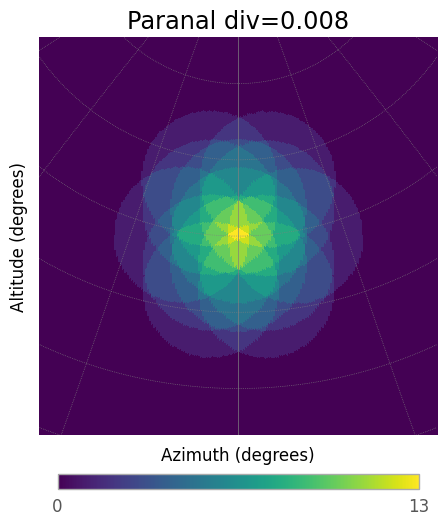

In [32]:
#complete_array.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=full_array, div1=0.008, div2=0.008, az=0, alt=70)
complete_array.divergent_pointing( div=0.008, az=0, alt=70)
complete_array.multiplicity_plot()



The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  7.25it/s]
46it [00:06,  6.84it/s]


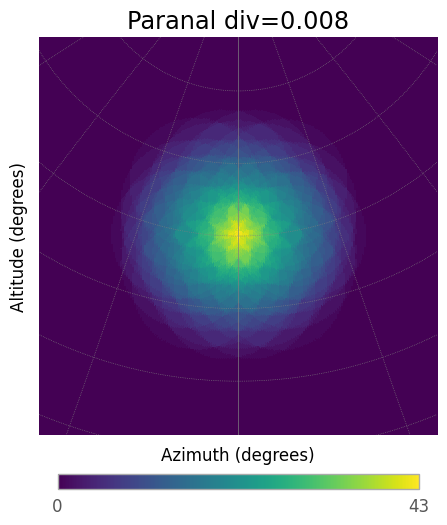

In [33]:
full_array.divergent_pointing(div=0.008,az=0, alt=70)
full_array.multiplicity_plot()


In [34]:
full_array.hFoV()

46it [00:06,  6.85it/s]


(239.4478541861046, 11.947532723588367)

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.222120825704168 rad
-0.0 rad
1.189082111560649 rad
-0.08547884876417715 rad
1.1895383811626927 rad
0.08547884876417715 rad
1.1894492050480268 rad
-0.0 rad
1.2521943898540595 rad
0.10376783219523598 rad
1.2513663579851608 rad
-0.10376783219523598 rad
1.2543966727348794 rad
-0.0 rad


6it [00:00,  6.68it/s]
7it [00:01,  6.56it/s]
6it [00:00,  6.37it/s]


10.386999382873206


7it [00:01,  6.75it/s]


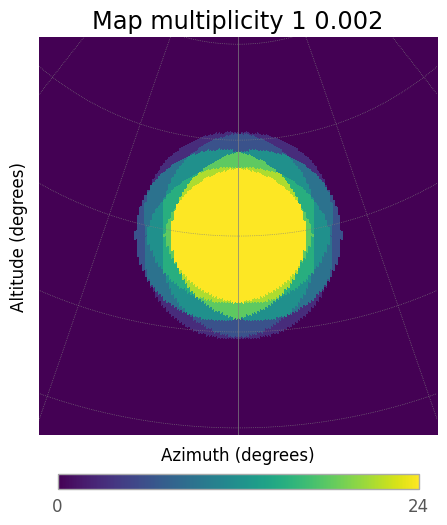

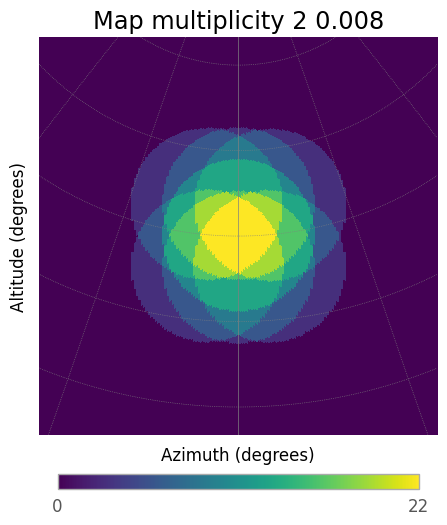

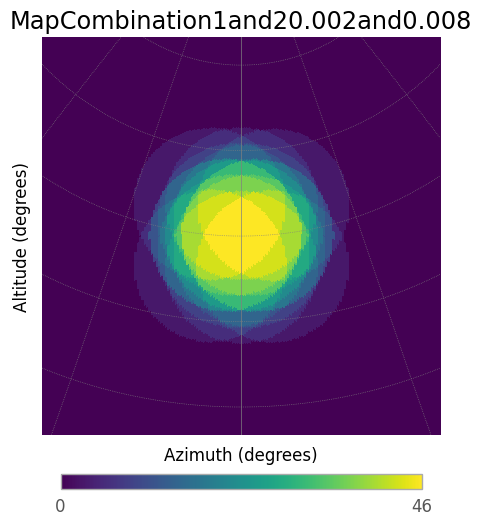

In [35]:
array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=0.002, div2=0.008, az=0, alt=70)
array_conv.multiplicity_plot_2_div(array_div, subarray_mult_1=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div)


In [36]:
divergence_list=[0.0022, 0.0043, 0.008, 0.01135, 0.013]

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  6.53it/s]
46it [00:06,  6.79it/s]
46it [00:06,  6.67it/s]
46it [00:06,  6.62it/s]


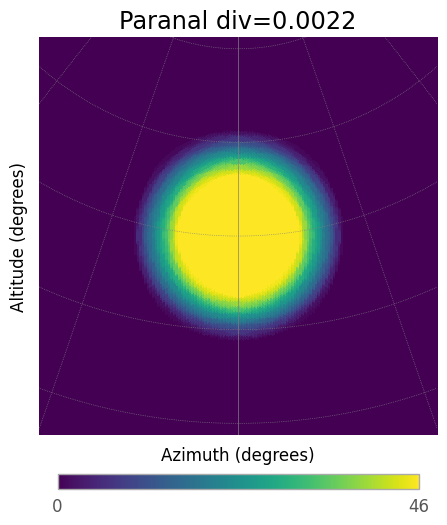

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  6.60it/s]
46it [00:07,  6.46it/s]
46it [00:07,  6.51it/s]
46it [00:07,  6.09it/s]


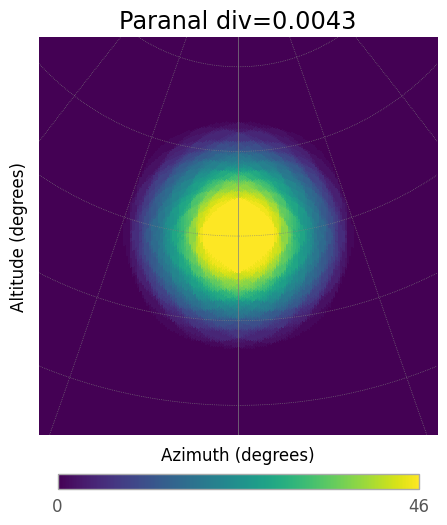

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  6.18it/s]
46it [00:07,  6.07it/s]
46it [00:07,  6.06it/s]
46it [00:07,  5.82it/s]


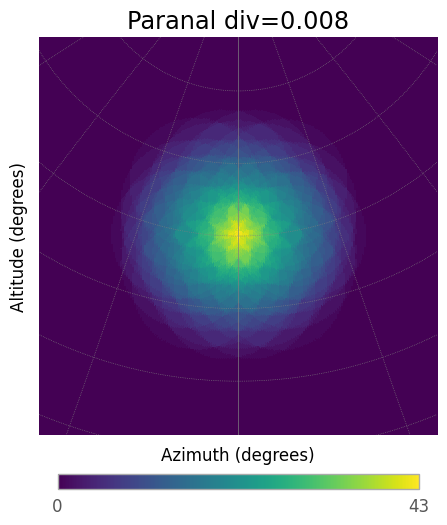

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  6.22it/s]
46it [00:07,  6.20it/s]
46it [00:07,  6.08it/s]
46it [00:07,  5.94it/s]


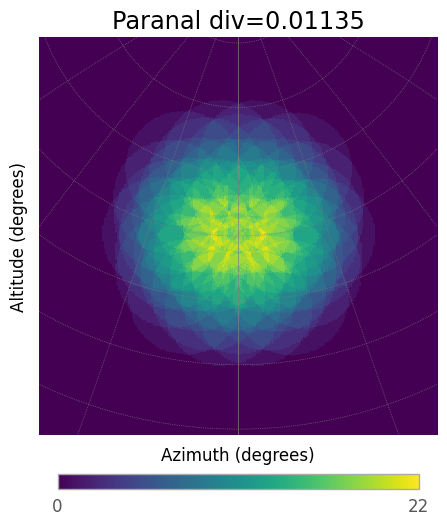

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  6.03it/s]
46it [00:07,  6.05it/s]
46it [00:07,  6.10it/s]
46it [00:07,  5.77it/s]


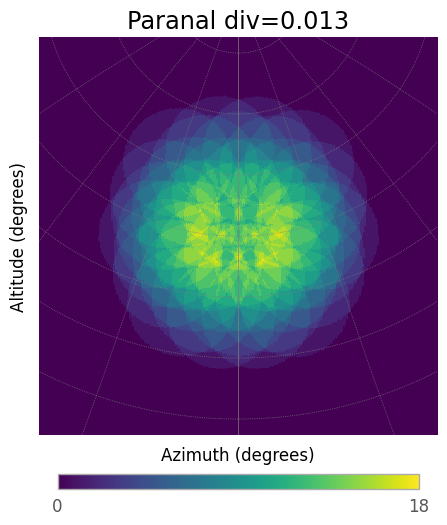

In [37]:
full_array_FoV_cut=[]
full_array_av_m_cut=[]
for divergence in divergence_list:   
    full_array.divergent_pointing(div=divergence, az=0, alt=70)
    full_array_FoV_cut.append(full_array.hFoV(m_cut=3)[0])
    full_array_av_m_cut.append(full_array.hFoV(m_cut=3)[1])
    full_array.multiplicity_plot()

In [38]:
full_array_FoV=[]
full_array_av_m=[]
for divergence in divergence_list:   
    full_array.divergent_pointing(div=divergence, az=0, alt=70)
    full_array_FoV.append(full_array.hFoV()[0])
    full_array_av_m.append(full_array.hFoV()[1])
    #complete_array.multiplicity_plot()

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:08,  5.71it/s]
46it [00:07,  5.77it/s]


The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  5.76it/s]
46it [00:08,  5.75it/s]


The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:08,  5.72it/s]
46it [00:07,  5.96it/s]


The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:08,  5.72it/s]
46it [00:07,  5.92it/s]


The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  5.97it/s]
46it [00:07,  5.94it/s]


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.221837773865566 rad
-0.0 rad
1.2129291541744542 rad
-0.025178426011643846 rad
1.213048216427508 rad
0.025178426011643846 rad
1.2127806189394152 rad
-0.0 rad
1.2303769438743488 rad
0.026561135767256355 rad
1.2301361746872446 rad
-0.026561135767256355 rad
1.230640506364589 rad
-0.0 rad


6it [00:00,  6.01it/s]
7it [00:01,  5.91it/s]
6it [00:01,  5.46it/s]


10.477672692584962


7it [00:01,  5.63it/s]


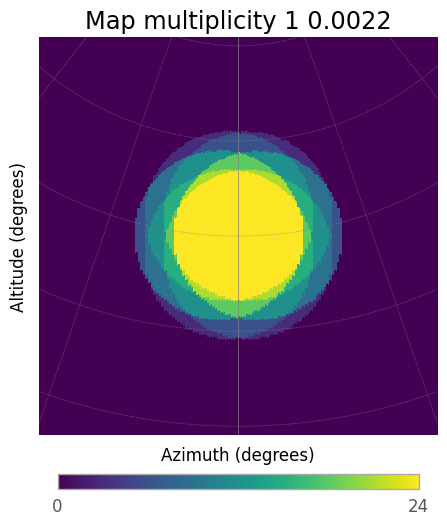

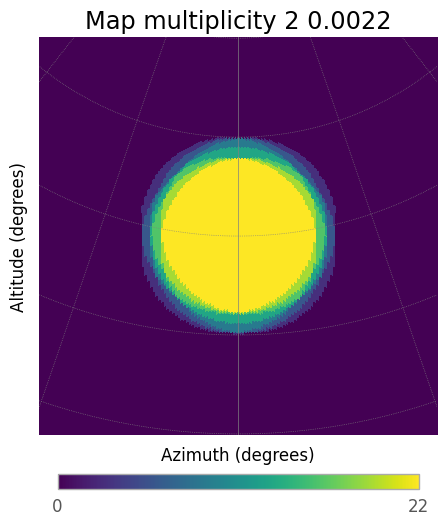

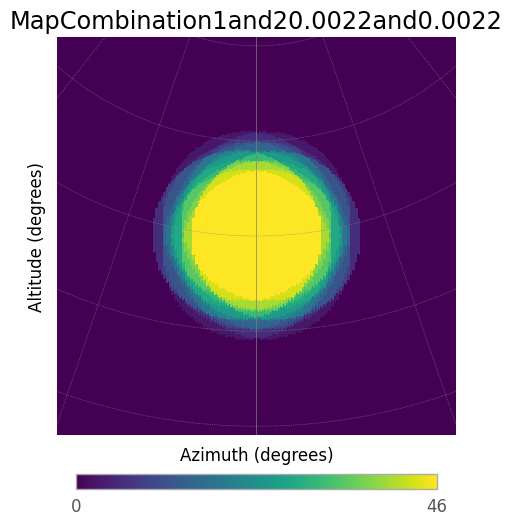

In [39]:
array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=0.0022, div2=0.0022, az=0, alt=70)
array_conv.multiplicity_plot_2_div(array_div, subarray_mult_1=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div)



The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  5.92it/s]
46it [00:07,  5.92it/s]


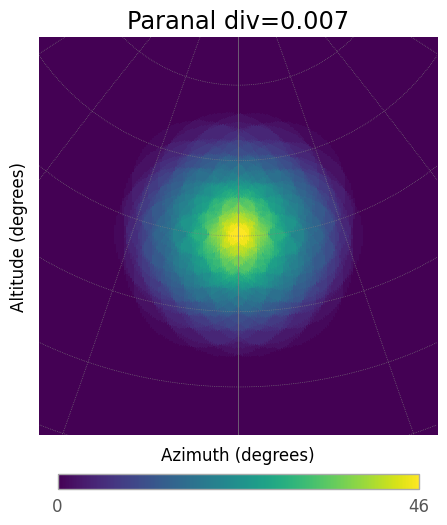

In [40]:
full_array.divergent_pointing(div=0.007, az=0, alt=70)
full_array.multiplicity_plot()

The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:07,  5.91it/s]
46it [00:07,  5.84it/s]


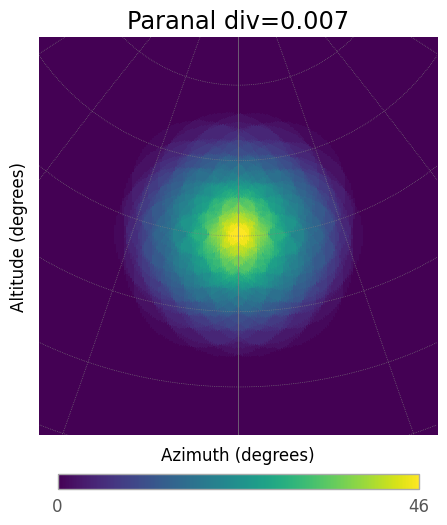

In [41]:
full_array.divergent_pointing(div=0.007, az=0, alt=70)
full_array.multiplicity_plot()

In [42]:
full_array.hFoV()

46it [00:07,  5.95it/s]


(211.48888463000762, 13.524958144726236)

In [43]:
array_conv.hFoV_for_2_arrays(array_2=array_div, subarray_mult=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div)

6it [00:01,  5.44it/s]
7it [00:01,  5.64it/s]


(94.26316752777917, 30.334168057874233)

In [44]:
## here we can play around a bit with the same number as before only that we stop at 0.013
#The idea could be to do an if lets see if I am able to do it 

# CHOOSING THE DIFFERENT CONVERGENCES
## DIV lets try 0.0022, 0.0043, 0.008, 0.01135, 0.013

The barycenter -1.1557142857142904
The barycenter 0.0
The barycenter 24.595714285714287


7it [00:01,  5.77it/s]
7it [00:01,  5.79it/s]


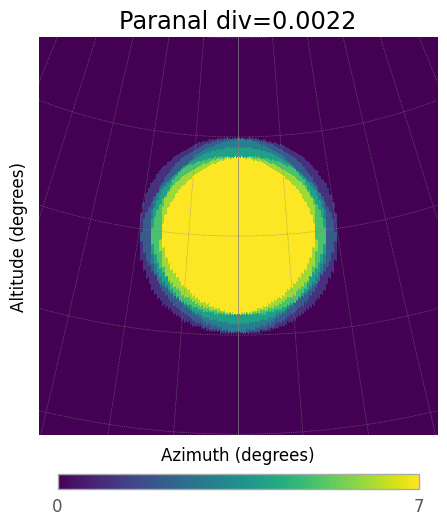

In [45]:
array_div.divergent_pointing(div=0.0022, az=0, alt=60)
array_div.multiplicity_plot()

In [46]:
array_div.hFoV(subarray_mult=number_of_telescopes_config_SST_div)

7it [00:01,  5.79it/s]


(80.33613860255637, 17.021384263793667)

In [47]:
hFoV_to_stop=array_div.hFoV(subarray_mult=number_of_telescopes_config_SST_div,m_cut=21)[0]

7it [00:01,  5.71it/s]


In [48]:
hFoV_to_stop

45.977555001724234

In [49]:
full_array

In [50]:
conv=np.linspace(-0.0035,-0.0011, 20)
for convergence in conv:
    array_conv.divergent_pointing(complete_array=complete_array,div=convergence, az=0, alt=70)
    hFoV_conv=array_conv.hFoV(subarray_mult=number_of_telescopes_config_SST_conv,m_cut=23)[0]
    print(array_conv.hFoV(subarray_mult=number_of_telescopes_config_SST_conv,m_cut=23)[0])
    if hFoV_conv > hFoV_to_stop:
        convergence_to_stop=convergence
        print(f"stop, the {convergence}")
        break 

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


6it [00:01,  5.91it/s]
6it [00:01,  5.70it/s]


23.9985526677568
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


6it [00:01,  5.97it/s]
6it [00:01,  5.94it/s]


24.955871981825787
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


...

44.089144299999106
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


6it [00:01,  5.86it/s]
6it [00:01,  5.84it/s]


45.38742665743513
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


6it [00:01,  5.73it/s]
6it [00:01,  5.75it/s]

46.908646389380365
stop, the -0.0012263157894736839


In [51]:
convergence_to_stop

-0.0012263157894736839

In [52]:
conv=np.linspace(-0.0083,-0.0012, 100)
convergence_list=[]
divergence_list=[0.0022, 0.0043, 0.008, 0.01135, 0.013]
for divergence in divergence_list:
    for convergence in conv:
        array_div.divergent_pointing(complete_array=complete_array,div=divergence, az=0, alt=70)
        hFoV_to_stop=array_div.hFoV(subarray_mult=number_of_telescopes_config_SST_div,m_cut=21)[0]
        array_conv.divergent_pointing(complete_array=complete_array, div=convergence, az=0, alt=70)
        hFoV_conv=array_conv.hFoV(subarray_mult=number_of_telescopes_config_SST_conv,m_cut=23)[0]
        if hFoV_conv > hFoV_to_stop:
            convergence=round(convergence,5)
            convergence_list.append(convergence)
            print(f"stop, the {convergence}")
            break 

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


7it [00:01,  5.87it/s]


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


6it [00:01,  5.84it/s]


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


...

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


7it [00:01,  5.94it/s]


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847


6it [00:01,  5.79it/s]

stop, the -0.00823


In [53]:
# Here i am not using the one that I normally use for the pointing with the corresponding barycenter because i am trying just to make an estimate

In [64]:
from astropy.coordinates import Angle
def multiplicity_plot_2_div(array, array_2, radius=None, subarray_mult_1=None, subarray_mult_2=None, fig1=None, fig2=None, alt=None, az=None):
    """
    Plot multiplicity for two arrays. The first graph is just the first group of telescopes with the given divergence and the second is the second group of telescopes with their given divergence.
    And the last plot is a combiantion of both of them
    All the comments seen with the "#" is just to see that everything is working. The first part there is a comment from rad to deg because I had a mistake with it, but I am wokring on implementing the lines

    Parameters
    ----------
    array: Array object
        First array of telescopes
    array_2: Array object
        Second array of telescopes
    subarray_mult: array_like, optional
        Multiplicities for the telescopes (default is 1 for all)
        This is used for the subarrays
     subarray_mult_2: array_like, optional
        Multiplicities for the telescopes (default is 1 for all)
        This is used for the subarrays
    fig1: matplotlib.figure.Figure, optional
        First figure for array plot
    fig2: matplotlib.figure.Figure, optional
        Second figure for array_2 plot
    """
    if array.table.units == 'rad':
        array.__convert_units__(toDeg=True)
    
    if array_2.table.units == 'rad':
        array_2.__convert_units__(toDeg=True)
   
    # Get pointing coordinates for both arrays
    coord_1 = array.get_pointing_coord(icrs=False)
    #print(f"The coordinates are {coord_1}")
    coord_2 = array_2.get_pointing_coord(icrs=False)
    
    # Set Healpix resolution (nside)
    nside = 512
    map_multiplicity_1 = np.zeros(hp.nside2npix(nside), dtype=np.float64)
    map_multiplicity_2 = np.zeros(hp.nside2npix(nside), dtype=np.float64)

    # Initialize Healpix coordinates
    counter = np.arange(0, hp.nside2npix(nside))
    ra, dec = hp.pix2ang(nside, counter, True, lonlat=True)
    coordinate = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    # Set multiplicities if not provided
    if subarray_mult_1 is None:
        subarray_mult_1 = np.ones(len(array.telescopes))
    if subarray_mult_2 is None:
        subarray_mult_2 = np.ones(len(array_2.telescopes))
   # total_number= len(array.telescopes) + len(array_2.telescopes)
   # Plotting for both arrays
    for i, tel in tqdm.tqdm(enumerate(array.telescopes)):
            # This is for array.telescopes
        #Trying to see if this works and then try to reput it in a more general way
            pointing = SkyCoord(ra=(coord_1.az[i].degree), dec=coord_1.alt[i].degree, unit='deg')
            #print(f"The az where it is pointing is: {coord_1.az[i].degree}")
            r_fov = np.arctan((tel.camera_radius / tel.focal).to(u.dimensionless_unscaled)).to(u.deg)
            mask = coordinate.separation(pointing) < r_fov
            map_multiplicity_1[mask] += subarray_mult_1[i]
            #print(map_multiplicity_1[mask])
    for i, tel in tqdm.tqdm(enumerate(array_2.telescopes)):
            # This is for array_2.telescopes
            #index_2 = i - len(array.telescopes)
            pointing_2 = SkyCoord(ra=coord_2.az[i].degree, dec=coord_2.alt[i].degree, unit='deg')
            r_fov_2 = np.arctan((tel.camera_radius / tel.focal).to(u.dimensionless_unscaled)).to(u.deg)
            mask_2 = coordinate.separation(pointing_2) < r_fov_2
            map_multiplicity_2[mask_2] += subarray_mult_2[i]
    #Trying to find the bigest R between the different configurations and taking that as universal
    R1 = np.sqrt(array.hFoV()[0] / np.pi) + 5
    print(R1)
    #print(array.table['fov'])
    #print(array_2.table['fov'])
    R2 = np.sqrt(array_2.hFoV()[0] / np.pi) + 5
    if R1>R2:
        R=R1
    else:
        R=R2 
    #The fist multiplicity plot
   
    hp.cartview(map_multiplicity_1, rot=[array.pointing["az"].value,
                                                      array.pointing["alt"].value],
                             lonra=[-R1, R1], latra=[-R1, R1],  cmap='viridis', nest=True,
                             return_projected_map=True, title=f"Map multiplicity 1 {array.div}")
    hp.graticule(dpar=5, dmer=5, coord='G', color='gray', lw=0.5)
    #print("The second map is")
    #The secod multiplicity plot 
    plt.annotate('Azimuth (degrees)', xy=(0.5, -0.05), xycoords='axes fraction', ha='center', va='center')
    plt.annotate('Altitude (degrees)', 
                     xy=(-0.05, 0.5), xycoords='axes fraction', 
                     ha='center', va='center', rotation='vertical')
    hp.cartview(map_multiplicity_2, rot=[array_2.pointing["az"].value,
                                                      array_2.pointing["alt"].value],
                         lonra=[-R2, R2], latra=[-R2, R2], cmap='viridis', nest=True,
                             return_projected_map=True, title=f"Map multiplicity 2 {array_2.div}")
    hp.graticule(dpar=5, dmer=5, coord='G', color='gray', lw=0.5)
    plt.annotate('Azimuth (degrees)', xy=(0.5, -0.05), xycoords='axes fraction', ha='center', va='center')
    plt.annotate('Altitude (degrees)', 
                     xy=(-0.05, 0.5), xycoords='axes fraction', 
                     ha='center', va='center', rotation='vertical')
    #The combination of both of them 
    hp.cartview(
        map_multiplicity_1+map_multiplicity_2,rot=[array.pointing["az"].value,
                                                      array.pointing["alt"].value],
                             lonra=[-R, R], latra=[-R, R],  cmap='viridis', nest=True,
                             return_projected_map=True, title=f"MapCombination1and2{array.div}and{array_2.div}")
    hp.graticule(dpar=5, dmer=5, coord='G', color='gray', lw=0.5)
    plt.annotate('Azimuth (degrees)', xy=(0.5, -0.05), xycoords='axes fraction', ha='center', va='center')
    plt.annotate('Altitude (degrees)', 
                     xy=(-0.05, 0.5), xycoords='axes fraction', 
                     ha='center', va='center', rotation='vertical')



     # ---- ADD A RING HERE ----
    az_center = az * u.deg
    alt_center= alt * u.deg
    center = SkyCoord(az=az_center, alt=alt_center, frame='altaz')
    angles = Angle(np.linspace(0, 2*np.pi, 200), unit=u.rad)  # Position angles around the center
    ring_radius = radius *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
  
   
    hp.projplot(lon, lat, '-', lonlat=True, linewidth=1.5, color='orange')
    print(az)
    print(alt)
##SST FoV
    ring_radius = 4.4 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    hp.projplot(lon, lat, '-', lonlat=True, linewidth=1.5, color='red')



    ## The different telescopes
    ##GRB SHORT 
    ring_radius = 2.2 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
   # hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='maroon')

    ## GRB short maximum 

    ring_radius = 4 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
   # hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='maroon')

##WORST LONG GRB
    ring_radius = 5 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
    hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='white')

    ##BEST LONG GRB
    ring_radius = 1.5 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    #hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='white')


    
    center = SkyCoord(az=az*u.deg, alt=alt*u.deg, frame='altaz')

    # Offset at angle θ = 45°
    theta = 0 * u.deg
    separation = 0 * u.deg
    point_on_ring = center.directional_offset_by(position_angle=theta, separation=separation)

# Plot it
    hp.projscatter(point_on_ring.az.deg, point_on_ring.alt.deg, lonlat=True,
               marker='x', color='red', s=100)
    # -------------------------- 

    plt.show()


    


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.221837773865566 rad
-0.0 rad
1.2129291541744542 rad
-0.025178426011643846 rad
1.213048216427508 rad
0.025178426011643846 rad
1.2127806189394152 rad
-0.0 rad
1.2303769438743488 rad
0.026561135767256355 rad
1.2301361746872446 rad
-0.026561135767256355 rad
1.230640506364589 rad
-0.0 rad


6it [00:01,  5.72it/s]
7it [00:01,  5.84it/s]
6it [00:01,  5.68it/s]


10.077450378074385


7it [00:01,  6.00it/s]


0
70


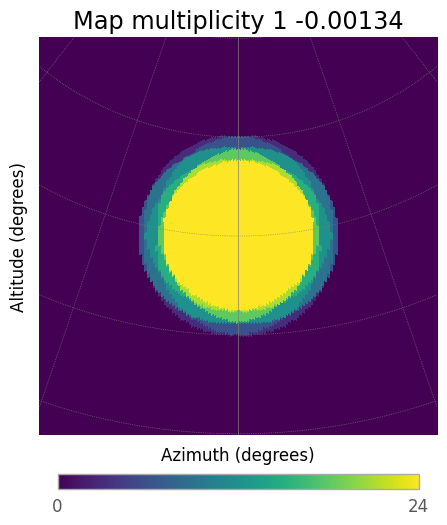

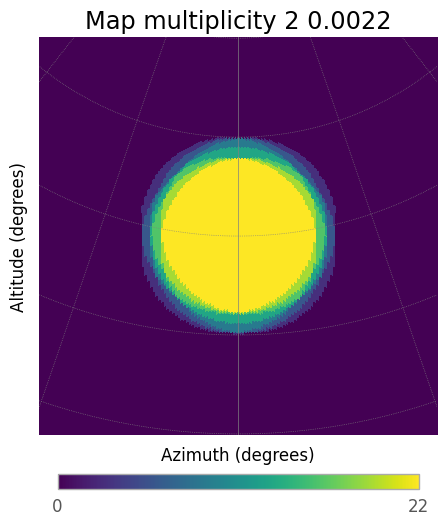

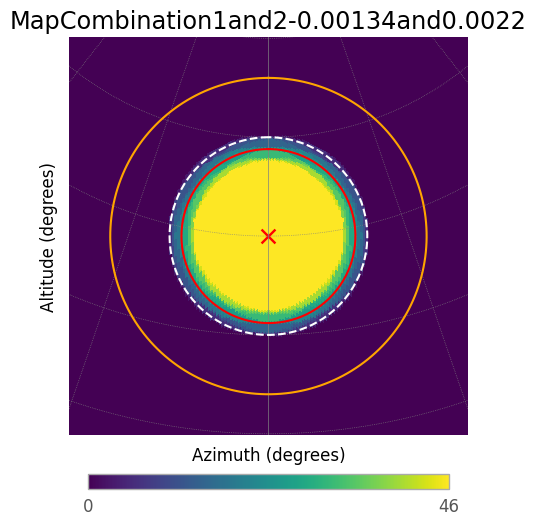

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2219402277399039 rad
-0.0 rad
1.2043925465804042 rad
-0.0479904988656012 rad
1.2046298056495823 rad
0.0479904988656012 rad
1.2042884867924208 rad
-0.0 rad
1.2384529599364629 rad
0.0532730716377664 rad
1.2379917161768568 rad
-0.0532730716377664 rad
1.2391977379163566 rad
-0.0 rad


6it [00:01,  5.85it/s]
7it [00:01,  5.87it/s]
6it [00:01,  5.55it/s]


10.6793351773081


7it [00:01,  5.80it/s]


0
70


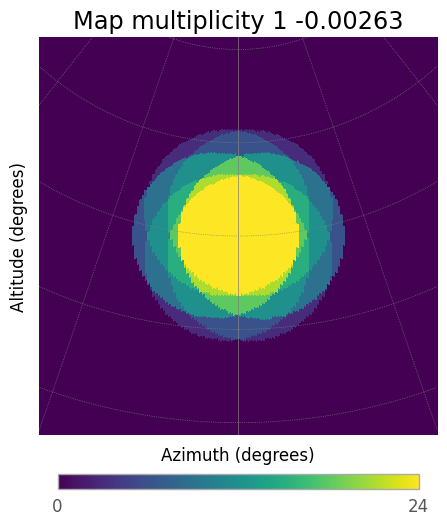

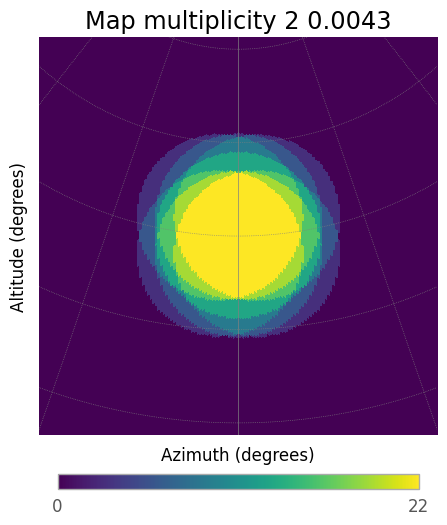

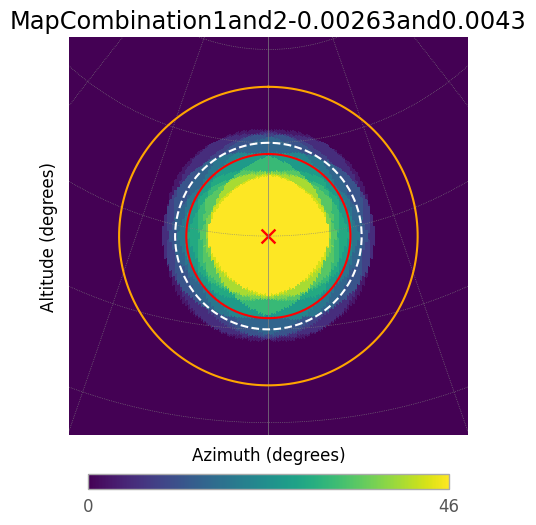

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.222120825704168 rad
-0.0 rad
1.189082111560649 rad
-0.08547884876417715 rad
1.1895383811626927 rad
0.08547884876417715 rad
1.1894492050480268 rad
-0.0 rad
1.2521943898540595 rad
0.10376783219523598 rad
1.2513663579851608 rad
-0.10376783219523598 rad
1.2543966727348794 rad
-0.0 rad


6it [00:01,  5.85it/s]
7it [00:01,  5.76it/s]
6it [00:01,  5.56it/s]


11.754020698401964


7it [00:01,  5.69it/s]


0
70


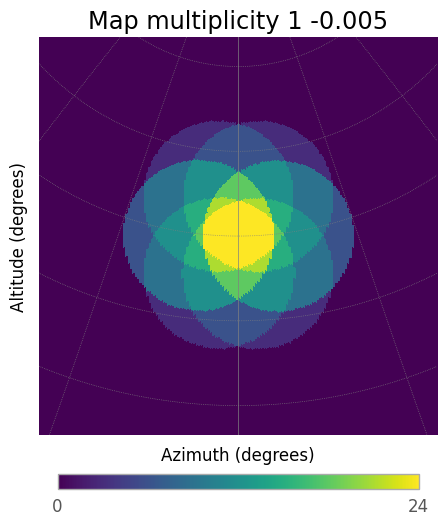

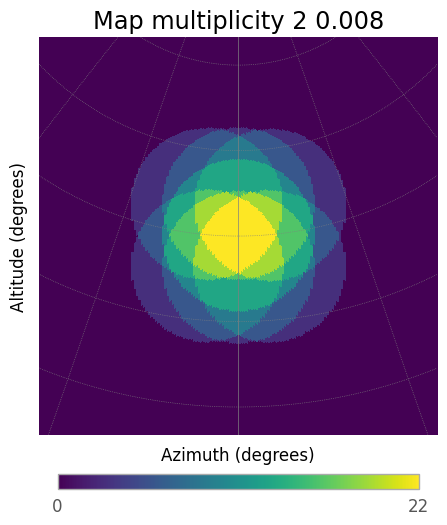

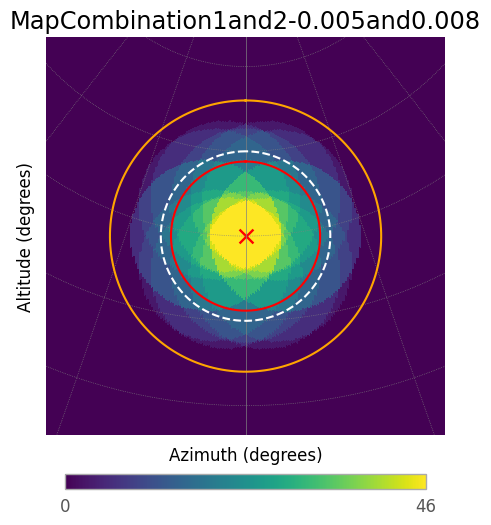

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2222844378552749 rad
-0.0 rad
1.174982099700631 rad
-0.11668434568238038 rad
1.175648326770499 rad
0.11668434568238038 rad
1.1761514501071109 rad
-0.0 rad
1.2640084898923605 rad
0.15350516525433922 rad
1.2628711151349332 rad
-0.15350516525433922 rad
1.268289130738942 rad
-0.0 rad


6it [00:01,  5.72it/s]
7it [00:01,  5.62it/s]
6it [00:01,  5.46it/s]


12.733925520704616


7it [00:01,  5.78it/s]


0
70


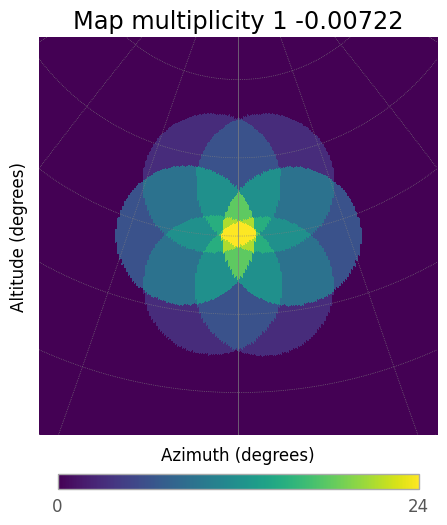

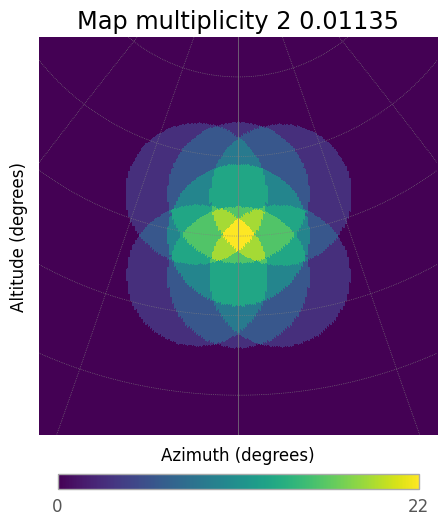

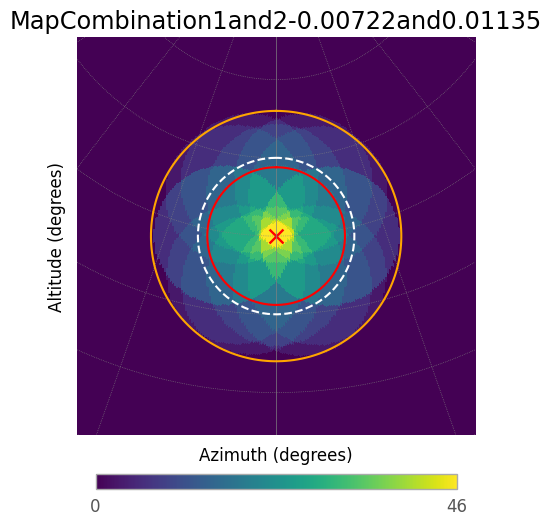

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2223650588765775 rad
-0.0 rad
1.1679719740259311 rad
-0.1311735431249487 rad
1.1687455961982909 rad
0.1311735431249487 rad
1.169650686662978 rad
-0.0 rad
1.2695757146601427 rad
0.1794797475927617 rad
1.268293421520115 rad
-0.1794797475927617 rad
1.2751765105195842 rad
-0.0 rad


6it [00:01,  5.97it/s]
7it [00:01,  5.58it/s]
6it [00:01,  5.45it/s]


13.169635782884946


7it [00:01,  5.81it/s]


0
70


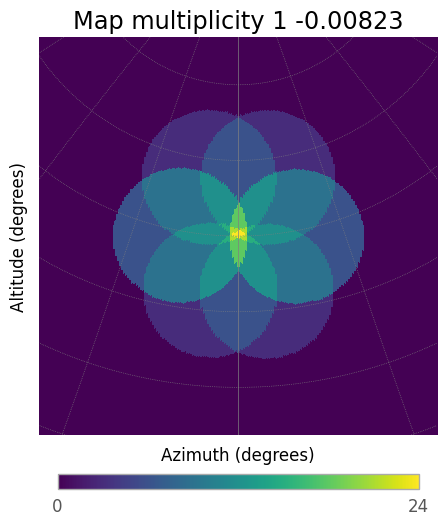

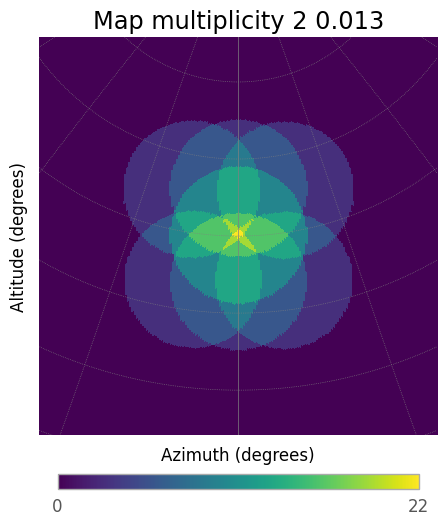

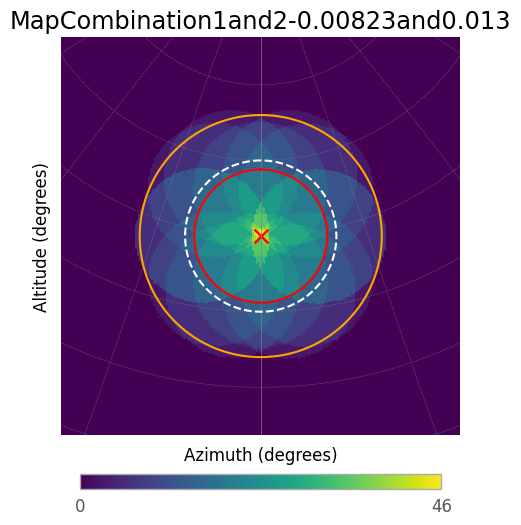

In [66]:
for i in range(5):
    array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=convergence_list[i], div2=divergence_list[i], az=0, alt=70)
    multiplicity_plot_2_div(array_conv,array_div, 8, subarray_mult_1=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div, alt=70, az=0)


In [ ]:
# To do the hFoV and the average multiplicity 

In [54]:
array_div.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-7.75,0.0,22.5,-0.000,70.036,19.964,5.600,4.450,62.462,0.341,0.000,0.940,8.77
2,415.67,402.0,12.42,352.484,66.920,23.080,5.600,4.450,62.462,0.389,0.051,0.920,578.95
3,415.67,-402.0,27.92,7.516,66.964,23.036,5.600,4.450,62.462,0.388,-0.051,0.920,578.74
4,429.33,0.0,16.08,-0.000,67.016,22.984,5.600,4.450,62.462,0.390,0.000,0.921,430.16
5,-415.67,-402.0,48.25,10.283,72.741,17.259,5.600,4.450,62.462,0.292,-0.053,0.955,578.14
6,-415.67,402.0,15.58,349.717,72.668,17.332,5.600,4.450,62.462,0.293,0.053,0.955,577.90
7,-429.67,0.0,29.42,-0.000,73.062,16.938,5.600,4.450,62.462,0.291,0.000,0.957,429.00


In [55]:
hFoV_SST=[]
average_multiplicity_SST=[]
for i in range(5):
    array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=convergence_list[i], div2=divergence_list[i], az=0, alt=70)
    hFoV_SST.append(array_conv.hFoV_for_2_arrays(array_2=array_div, subarray_mult=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div)[0])
    print(array_conv.hFoV_for_2_arrays(array_2=array_div, subarray_mult=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div))
    average_multiplicity_SST.append(array_conv.hFoV_for_2_arrays(array_2=array_div, subarray_mult=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div)[1])


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.221837773865566 rad
-0.0 rad
1.2129291541744542 rad
-0.025178426011643846 rad
1.213048216427508 rad
0.025178426011643846 rad
1.2127806189394152 rad
-0.0 rad
1.2303769438743488 rad
0.026561135767256355 rad
1.2301361746872446 rad
-0.026561135767256355 rad
1.230640506364589 rad
-0.0 rad


6it [00:00,  6.34it/s]
7it [00:01,  6.70it/s]
6it [00:00,  6.10it/s]
7it [00:01,  6.61it/s]


(81.98849796656586, 34.88083813179782)


6it [00:00,  6.37it/s]
7it [00:01,  6.88it/s]


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2219402277399039 rad
-0.0 rad
1.2043925465804042 rad
-0.0479904988656012 rad
1.2046298056495823 rad
0.0479904988656012 rad
1.2042884867924208 rad
-0.0 rad
1.2384529599364629 rad
0.0532730716377664 rad
1.2379917161768568 rad
-0.0532730716377664 rad
1.2391977379163566 rad
-0.0 rad


...

6it [00:00,  6.51it/s]
7it [00:01,  6.73it/s]


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2223650588765775 rad
-0.0 rad
1.1679719740259311 rad
-0.1311735431249487 rad
1.1687455961982909 rad
0.1311735431249487 rad
1.169650686662978 rad
-0.0 rad
1.2695757146601427 rad
0.1794797475927617 rad
1.268293421520115 rad
-0.1794797475927617 rad
1.2751765105195842 rad
-0.0 rad


6it [00:00,  6.40it/s]
7it [00:01,  6.76it/s]
6it [00:00,  6.48it/s]
7it [00:01,  6.53it/s]


(219.68511163402292, 13.013968481375358)


6it [00:01,  5.44it/s]
7it [00:01,  6.79it/s]


In [56]:
hFoV_SST

[81.98849796656586,
 103.66587914678553,
 148.06975856373882,
 195.48984951816973,
 219.68511163402292]

In [57]:
average_multiplicity_SST

[34.88083813179782,
 27.608602150537635,
 19.323974847223454,
 14.631984973502382,
 13.013968481375358]

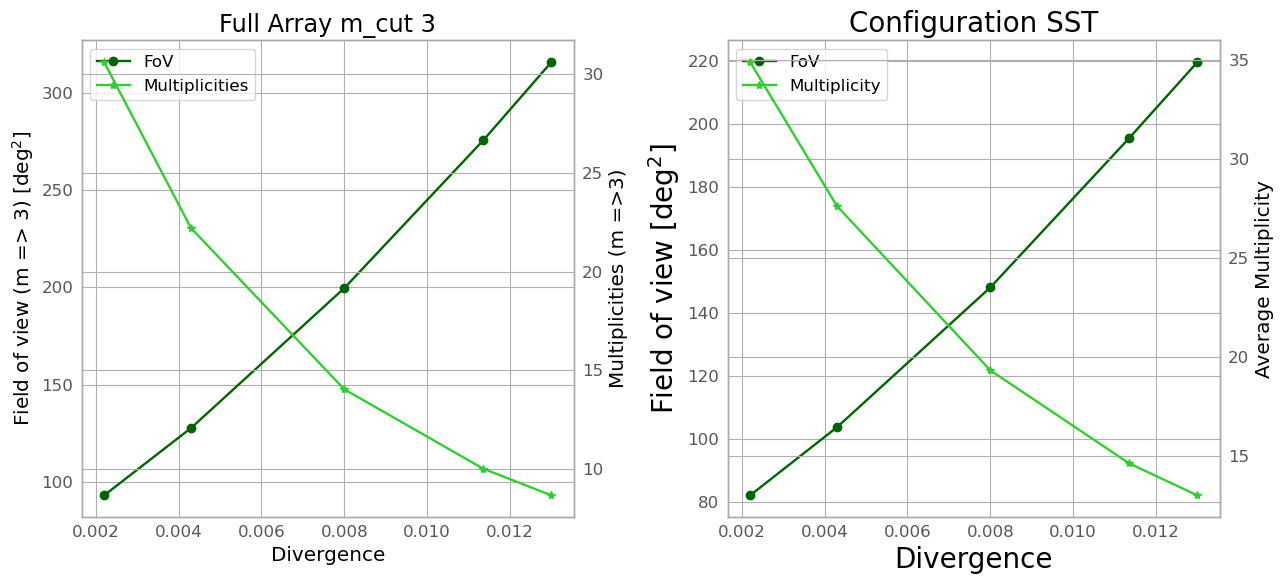

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6)) 
# Plot Full Array
 #Full Array with m_cut = 3
l1=axes[0].plot(divergence_list, full_array_FoV_cut, label='FoV', marker='o', color='darkgreen')
ax2 = axes[0].twinx()
l2=ax2.plot(divergence_list, full_array_av_m_cut, label='Multiplicities',marker='*', color='limegreen')
axes[0].set_title('Full Array m_cut 3')
axes[0].set_xlabel('Divergence')
axes[0].set_ylabel('Field of view (m => 3) [deg$^2$]')
ax2.set_ylabel('Multiplicities (m =>3)')
axeslegend = l1+l2
axes[0].legend(axeslegend, [l.get_label() for l in axeslegend])



#Plot the ones for subarray
l1=axes[1].plot(divergence_list,hFoV_SST, label='FoV',marker='o', color='darkgreen')
ax5=axes[1].twinx()
l2=ax5.plot(divergence_list, average_multiplicity_SST, label='Multiplicity', marker='*', color='limegreen')
axes[1].set_title('Configuration SST', fontsize='20')
axes[1].set_xlabel('Divergence', fontsize='20')
axes[1].set_ylabel('Field of view [deg$^2$]',  fontsize='20')
ax5.set_ylabel('Average Multiplicity')
axeslegend = l1+l2
axes[1].legend(axeslegend, [l.get_label() for l in axeslegend])
#Plot the ones for subarray 2

# Adjust layout
plt.tight_layout()
# Subarray 4
# Adjust layout
plt.show()

In [59]:
print( full_array_FoV_cut)


[93.18782254485237, 127.808685409813, 199.67320378101914, 275.48502507735907, 315.77112004749506]


In [60]:
print(full_array_av_m_cut)

[30.584717140444695, 22.192694438744102, 14.048469722842507, 10.041986004665112, 8.687362431994684]


In [61]:
print(full_array_FoV)

[99.9021717065417, 144.00442996974724, 239.4478541861046, 345.26442329874374, 403.60844560412625]


In [62]:
print(full_array_av_m)

[28.6315305854555, 19.86139695838266, 11.947532723588367, 8.286501063506533, 7.087922799493128]


In [63]:
print(hFoV_SST)

[81.98849796656586, 103.66587914678553, 148.06975856373882, 195.48984951816973, 219.68511163402292]


In [64]:
print(average_multiplicity_SST)

[34.88083813179782, 27.608602150537635, 19.323974847223454, 14.631984973502382, 13.013968481375358]


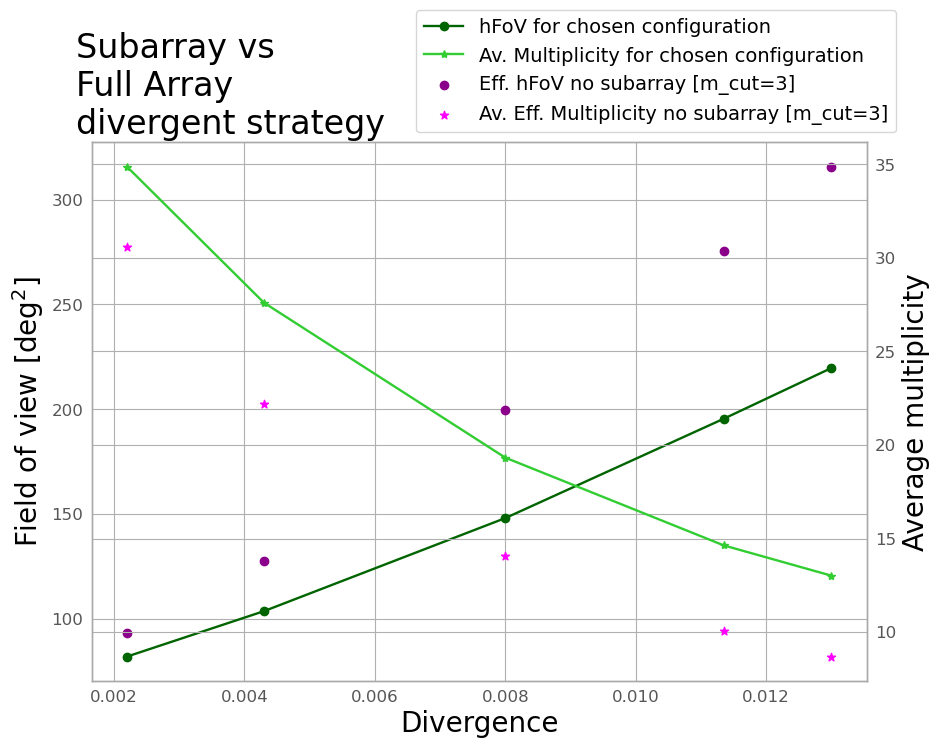

In [136]:
f, ax = plt.subplots(1, 1, figsize=(10, 7))

# Plot data
p1 = ax.plot(divergence_list, hFoV_SST, label='hFoV for chosen configuration', marker='o', color='darkgreen')
p3 = ax.scatter(divergence_list, full_array_FoV_cut, label='Eff. hFoV no subarray [m_cut=3]', marker='o', color='darkmagenta')

ax.set_xlabel('Divergence', fontsize=20)
ax.set_ylabel('Field of view [deg$^2$]', fontsize=20)

# Secondary y-axis
ax2 = ax.twinx()
p2 = ax2.plot(divergence_list, average_multiplicity_SST, label='Av. Multiplicity for chosen configuration', marker='*', color='limegreen')
p4 = ax2.scatter(divergence_list, full_array_av_m_cut, label='Av. Eff. Multiplicity no subarray [m_cut=3]', marker='*', color='magenta')
ax2.set_ylabel("Average multiplicity", fontsize=20)

# Combine all plots into one list for the legend
ps = p1 + p2 + [p3] + [p4]
labels = [p.get_label() for p in ps]

# Add title above the plot (left-aligned)
plt.title("Subarray vs\nFull Array\ndivergent strategy",x=-0.02, ha='left', fontsize=24)

# Place legend *above* the plot, right-aligned
ax.legend(ps, labels, loc='lower right', bbox_to_anchor=(1.05, 1), fontsize=14, ncol=1)

#plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for title and legend
plt.show()

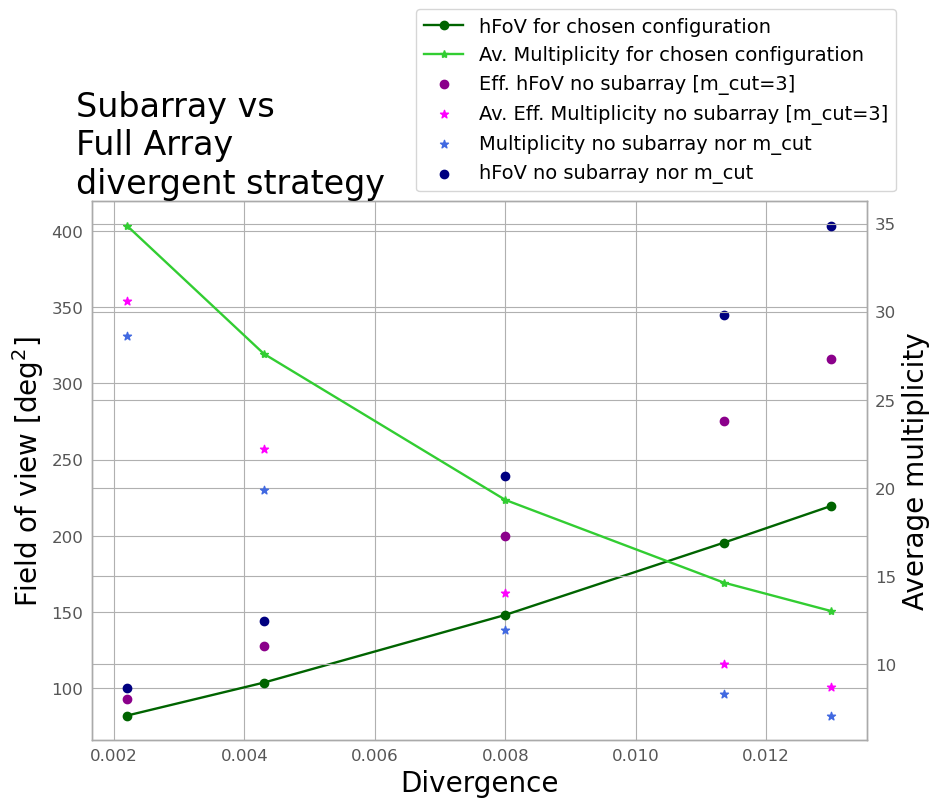

In [138]:
f, ax = plt.subplots(1, 1, figsize=(10, 7))

# Plot data
p1 = ax.plot(divergence_list, hFoV_SST, label='hFoV for chosen configuration', marker='o', color='darkgreen')
p3 = ax.scatter(divergence_list, full_array_FoV_cut, label='Eff. hFoV no subarray [m_cut=3]', marker='o', color='darkmagenta')
p7 = ax.scatter(divergence_list, full_array_FoV, label='hFoV no subarray nor m_cut', marker='o', color='navy')
ax.set_xlabel('Divergence', fontsize=20)
ax.set_ylabel('Field of view [deg$^2$]', fontsize=20)

# Secondary y-axis
ax2 = ax.twinx()
p2 = ax2.plot(divergence_list, average_multiplicity_SST, label='Av. Multiplicity for chosen configuration', marker='*', color='limegreen')
p4 = ax2.scatter(divergence_list, full_array_av_m_cut, label='Av. Eff. Multiplicity no subarray [m_cut=3]', marker='*', color='magenta')
p6 = ax2.scatter(divergence_list, full_array_av_m, label='Multiplicity no subarray nor m_cut', marker='*', color='royalblue')
ax2.set_ylabel("Average multiplicity", fontsize=20)

plt.title("Subarray vs\nFull Array\ndivergent strategy",x=-0.02, ha='left', fontsize=24)



ps = p1 + p2 + [p3] + [p4] + [p6] + [p7]
labels = [p.get_label() for p in ps]
ax.legend(ps, labels, loc='lower right', bbox_to_anchor=(1.05, 1), fontsize=14, ncol=1)
plt.show()

In [ ]:
complete_array.table

In [123]:
array_div.table


id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-7.75,0.0,22.5,-0.000,70.036,19.964,5.600,4.450,62.462,0.341,0.000,0.940,8.77
2,415.67,402.0,12.42,352.484,66.920,23.080,5.600,4.450,62.462,0.389,0.051,0.920,578.95
3,415.67,-402.0,27.92,7.516,66.964,23.036,5.600,4.450,62.462,0.388,-0.051,0.920,578.74
4,429.33,0.0,16.08,-0.000,67.016,22.984,5.600,4.450,62.462,0.390,0.000,0.921,430.16
5,-415.67,-402.0,48.25,10.283,72.741,17.259,5.600,4.450,62.462,0.292,-0.053,0.955,578.14
6,-415.67,402.0,15.58,349.717,72.668,17.332,5.600,4.450,62.462,0.293,0.053,0.955,577.90
7,-429.67,0.0,29.42,-0.000,73.062,16.938,5.600,4.450,62.462,0.291,0.000,0.957,429.00


In [124]:
array_conv.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,11.122,69.661,20.339,5.600,4.450,62.462,0.341,-0.067,0.938,816.85
2,-840.0,404.67,16.75,4.632,66.323,23.677,5.600,4.450,62.462,0.400,-0.032,0.916,931.85
3,-840.0,-404.67,55.92,355.368,66.250,23.750,5.600,4.450,62.462,0.401,0.033,0.915,932.21
4,0.0,-816.83,65.42,348.878,69.589,20.411,5.600,4.450,62.462,0.342,0.067,0.937,817.70
5,839.67,-404.67,17.75,353.041,73.708,16.292,5.600,4.450,62.462,0.278,0.034,0.960,932.76
6,839.67,404.67,10.08,6.959,73.718,16.282,5.600,4.450,62.462,0.278,-0.034,0.960,932.87


In [125]:
print(type(number_of_telescopes_config_SST_conv))

<class 'list'>


In [126]:
number_of_telescopes_config_SST_conv

[6, 3, 3, 6, 3, 3]

6it [00:00,  6.11it/s]
7it [00:01,  6.75it/s]
/Users/macbook/miniconda3/envs/divtel/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/macbook/miniconda3/envs/divtel/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
6it [00:00,  6.79it/s]
7it [00:01,  6.19it/s]
6it [00:00,  6.54it/s]
7it [00:01,  6.83it/s]
6it [00:00,  6.72it/s]
7it [00:01,  5.87it/s]
6it [00:00,  6.58it/s]
7it [00:01,  6.90it/s]
6it [00:00,  6.73it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.25it/s]
7it [00:01,  6.87it/s]
6it [00:00,  6.84it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.94it/s]
7it [00:01,  6.82it/s]
6it [00:00,  6.78it/s]
7it [00:01,  6.74it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.58it/s]
6it [00:00,  6.79it/s]
7it [00:01,  6.98it/s]
6it [00:00,  6.60it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.84it/s]
7

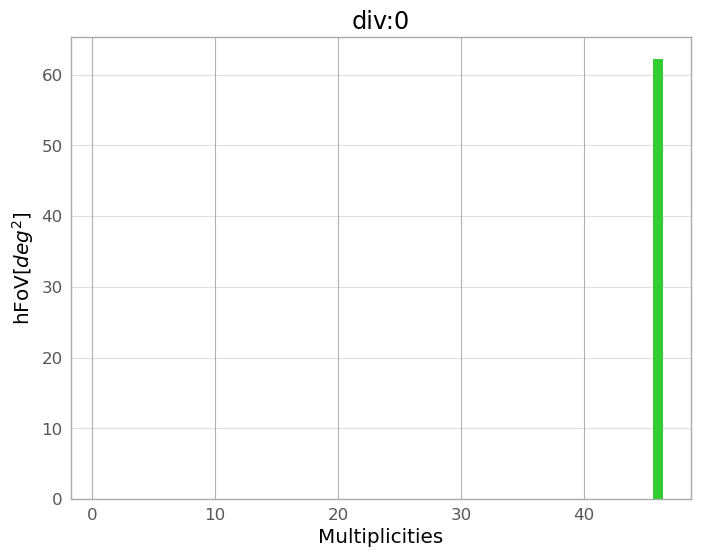

In [127]:
hFoV_graph=[]
multiplicities=[]
array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=0, div2=0, az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)
for j in range(46):
        hFoV_graph.append(array_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=2, array_2=array_div,subarray_mult_1=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div, m_cut=j)
[0])
        multiplicities.append(j+1)
plt.figure(figsize=(8, 6)) 
plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
plt.xlabel("Multiplicities")
plt.ylabel("hFoV[$deg^2$]")
plt.title(f"div:{0}")
plt.grid(axis='y', alpha=0.4)
plt.show()   


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.221837773865566 rad
-0.0 rad
1.2129291541744542 rad
-0.025178426011643846 rad
1.213048216427508 rad
0.025178426011643846 rad
1.2127806189394152 rad
-0.0 rad
1.2303769438743488 rad
0.026561135767256355 rad
1.2301361746872446 rad
-0.026561135767256355 rad
1.230640506364589 rad
-0.0 rad
The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  6.77it/s]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


6it [00:00,  6.55it/s]
7it [00:01,  6.90it/s]
6it [00:00,  6.94it/s]
7it [00:01,  6.80it/s]
6it [00:00,  6.83it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.78it/s]
7it [00:01,  6.63it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.84it/s]
6it [00:00,  6.52it/s]
7it [00:01,  6.87it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.79it/s]
6it [00:00,  6.82it/s]
7it [00:00,  7.00it/s]
6it [00:00,  6.90it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.82it/s]
7it [00:01,  3.55it/s]
6it [00:00,  6.84it/s]
7it [00:01,  6.98it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.93it/s]
6it [00:00,  6.97it/s]
7it [00:01,  6.68it/s]
6it [00:02,  2.53it/s]
7it [00:01,  6.05it/s]
6it [00:00,  6.04it/s]
7it [00:01,  6.28it/s]
6it [00:00,  6.25it/s]
7it [00:01,  6.46it/s]
6it [00:00,  6.39it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.75it/s]
7it [00:01,  6.74it/s]
6it [00:00,  6.88it/s]
7it [00:01,  6.87it/s]
6it [00:00,  6.91it/s]
7it [00:01,

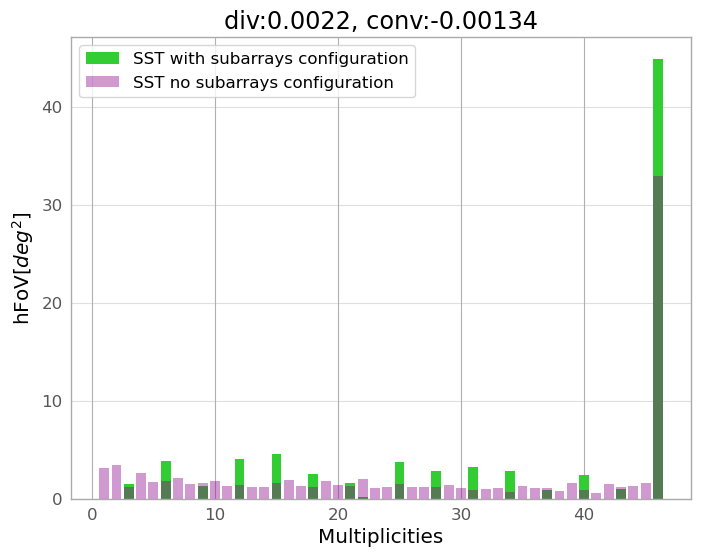

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2219402277399039 rad
-0.0 rad
1.2043925465804042 rad
-0.0479904988656012 rad
1.2046298056495823 rad
0.0479904988656012 rad
1.2042884867924208 rad
-0.0 rad
1.2384529599364629 rad
0.0532730716377664 rad
1.2379917161768568 rad
-0.0532730716377664 rad
1.2391977379163566 rad
-0.0 rad
The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  6.84it/s]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


6it [00:00,  6.51it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.93it/s]
6it [00:00,  6.62it/s]
7it [00:01,  6.76it/s]
6it [00:00,  6.81it/s]
7it [00:01,  6.17it/s]
6it [00:00,  6.40it/s]
7it [00:01,  6.77it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.91it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.87it/s]
7it [00:01,  6.81it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.83it/s]
6it [00:00,  6.81it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.34it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.94it/s]
7it [00:01,  6.88it/s]
6it [00:00,  6.90it/s]
7it [00:01,  6.86it/s]
6it [00:00,  6.75it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.83it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.97it/s]
7it [00:01,  6.67it/s]
6it [00:00,  6.85it/s]
7it [00:01,  6.92it/s]
6it [00:00,  6.97it/s]
7it [00:00,  7.01it/s]
6it [00:00,  6.60it/s]
7it [00:01,  6.84it/s]
6it [00:00,  6.93it/s]
7it [00:01,  6.90it/s]
6it [00:00,  6.98it/s]
7it [00:01,  6.88it/s]
6it [00:00,  6.89it/s]
7it [00:01,

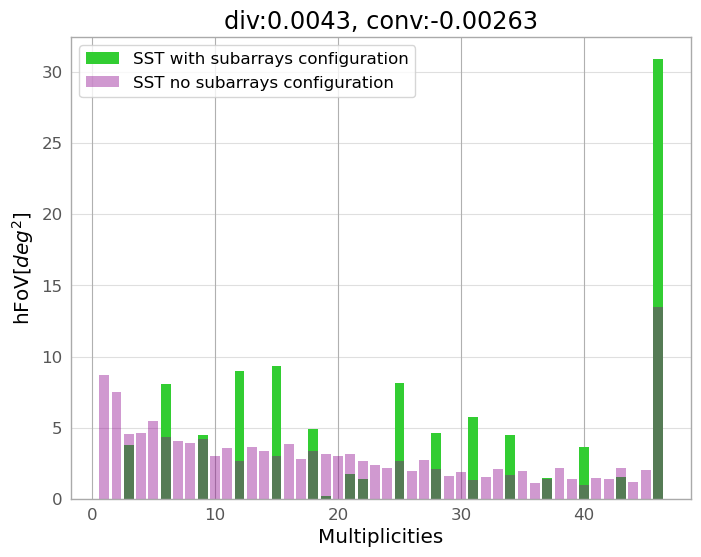

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.222120825704168 rad
-0.0 rad
1.189082111560649 rad
-0.08547884876417715 rad
1.1895383811626927 rad
0.08547884876417715 rad
1.1894492050480268 rad
-0.0 rad
1.2521943898540595 rad
0.10376783219523598 rad
1.2513663579851608 rad
-0.10376783219523598 rad
1.2543966727348794 rad
-0.0 rad
The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  6.97it/s]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


6it [00:00,  6.76it/s]
7it [00:01,  6.93it/s]
6it [00:00,  6.63it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.74it/s]
7it [00:01,  6.60it/s]
6it [00:00,  6.53it/s]
7it [00:01,  6.58it/s]
6it [00:00,  6.23it/s]
7it [00:01,  6.93it/s]
6it [00:00,  6.87it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.93it/s]
7it [00:00,  7.00it/s]
6it [00:00,  6.84it/s]
7it [00:01,  6.75it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.57it/s]
6it [00:00,  6.79it/s]
7it [00:01,  6.92it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.77it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.67it/s]
7it [00:01,  6.92it/s]
6it [00:00,  6.44it/s]
7it [00:01,  6.82it/s]
6it [00:00,  6.87it/s]
7it [00:01,  6.83it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.77it/s]
7it [00:01,  7.00it/s]
6it [00:00,  6.91it/s]
7it [00:01,  6.68it/s]
6it [00:00,  6.77it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.82it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.87it/s]
7it [00:01,  6.92it/s]
6it [00:00,  6.85it/s]
7it [00:01,

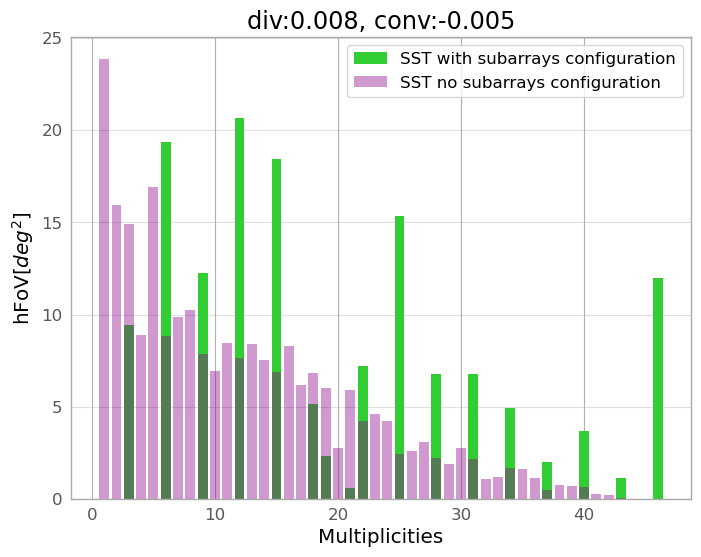

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2222844378552749 rad
-0.0 rad
1.174982099700631 rad
-0.11668434568238038 rad
1.175648326770499 rad
0.11668434568238038 rad
1.1761514501071109 rad
-0.0 rad
1.2640084898923605 rad
0.15350516525433922 rad
1.2628711151349332 rad
-0.15350516525433922 rad
1.268289130738942 rad
-0.0 rad
The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  6.71it/s]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


6it [00:00,  6.67it/s]
7it [00:01,  6.82it/s]
6it [00:00,  6.55it/s]
7it [00:01,  6.69it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.75it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.76it/s]
6it [00:00,  6.52it/s]
7it [00:01,  6.75it/s]
6it [00:00,  6.76it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.57it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.52it/s]
7it [00:01,  6.22it/s]
6it [00:00,  6.71it/s]
7it [00:01,  6.78it/s]
6it [00:00,  6.63it/s]
7it [00:01,  6.84it/s]
6it [00:00,  6.78it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.56it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.42it/s]
7it [00:01,  6.26it/s]
6it [00:00,  6.38it/s]
7it [00:01,  6.07it/s]
6it [00:00,  6.33it/s]
7it [00:01,  5.53it/s]
6it [00:01,  5.83it/s]
7it [00:01,  5.43it/s]
6it [00:00,  6.10it/s]
7it [00:01,  5.25it/s]
6it [00:00,  6.12it/s]
7it [00:01,  6.26it/s]
6it [00:00,  6.24it/s]
7it [00:01,  6.49it/s]
6it [00:00,  6.57it/s]
7it [00:01,  6.72it/s]
6it [00:00,  6.78it/s]
7it [00:01,  6.70it/s]
6it [00:01,  5.82it/s]
7it [00:01,

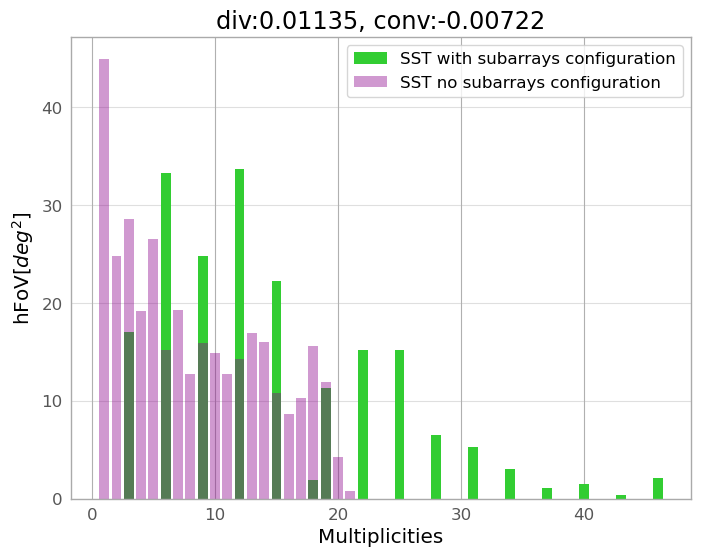

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2223650588765775 rad
-0.0 rad
1.1679719740259311 rad
-0.1311735431249487 rad
1.1687455961982909 rad
0.1311735431249487 rad
1.169650686662978 rad
-0.0 rad
1.2695757146601427 rad
0.1794797475927617 rad
1.268293421520115 rad
-0.1794797475927617 rad
1.2751765105195842 rad
-0.0 rad
The barycenter -0.7391304347826086
The barycenter 0.0
The barycenter 29.652173913043477


46it [00:06,  6.92it/s]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


6it [00:00,  6.66it/s]
7it [00:01,  6.95it/s]
6it [00:00,  6.73it/s]
7it [00:01,  6.65it/s]
6it [00:00,  6.79it/s]
7it [00:01,  6.84it/s]
6it [00:00,  6.82it/s]
7it [00:01,  6.93it/s]
6it [00:00,  6.81it/s]
7it [00:01,  6.93it/s]
6it [00:00,  6.83it/s]
7it [00:01,  6.60it/s]
6it [00:00,  6.37it/s]
7it [00:01,  6.69it/s]
6it [00:00,  6.82it/s]
7it [00:00,  7.01it/s]
6it [00:00,  6.12it/s]
7it [00:01,  6.79it/s]
6it [00:00,  6.47it/s]
7it [00:01,  6.49it/s]
6it [00:00,  6.72it/s]
7it [00:01,  6.38it/s]
6it [00:00,  6.73it/s]
7it [00:01,  6.86it/s]
6it [00:00,  6.81it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.87it/s]
6it [00:00,  6.74it/s]
7it [00:01,  6.79it/s]
6it [00:00,  6.78it/s]
7it [00:01,  6.95it/s]
6it [00:00,  6.63it/s]
7it [00:01,  6.70it/s]
6it [00:01,  5.89it/s]
7it [00:01,  6.87it/s]
6it [00:00,  6.86it/s]
7it [00:02,  2.58it/s]
6it [00:01,  5.14it/s]
7it [00:01,  6.06it/s]
6it [00:00,  6.38it/s]
7it [00:01,  6.57it/s]
6it [00:00,  6.69it/s]
7it [00:01,

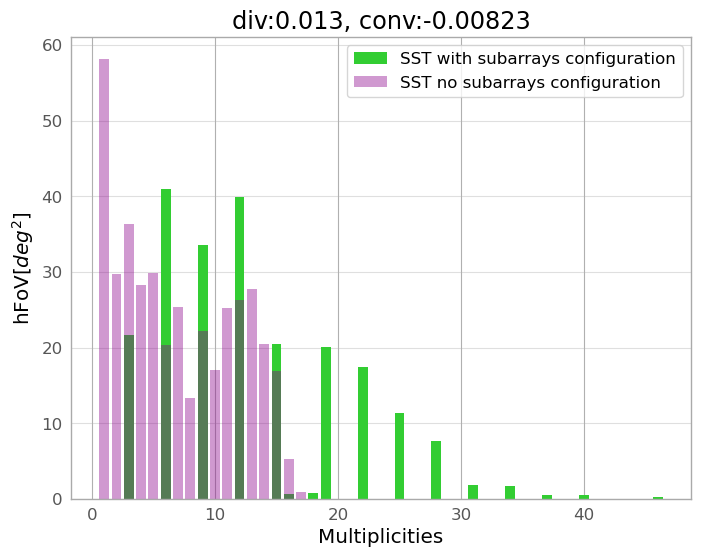

In [128]:
for i in range(5):
    hFoV_graph=[]
    multiplicities=[]
    hFoV_graph_full_array=[]
    #config_MST.divergent_pointing(div_MST[i], az=0,alt=70)
    array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=convergence_list[i], div2=divergence_list[i], az=0, alt=70)
    full_array.divergent_pointing(div=divergence_list[i], az=0, alt=70)
    hFoV_graph_full_array.append(full_array.hFoV_bar_graph(multiplicity_max=46)[0])
    for j in range(46):
        hFoV_graph.append(array_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=2, array_2=array_div,subarray_mult_1=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div, m_cut=j)
[0])
        multiplicities.append(j+1)
    plt.figure(figsize=(8, 6)) 
    plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen', label='SST with subarrays configuration')
    plt.bar(multiplicities, np.array(hFoV_graph_full_array[0]).flatten(), color='darkmagenta',alpha=0.4,label='SST no subarrays configuration')
    plt.xlabel("Multiplicities")
    plt.ylabel("hFoV[$deg^2$]")
    plt.legend()
    plt.title(f"div:{divergence_list[i]}, conv:{convergence_list[i]}")
    plt.grid(axis='y', alpha=0.4)
    plt.show()   


The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.221837773865566 rad
-0.0 rad
1.2129291541744542 rad
-0.025178426011643846 rad
1.213048216427508 rad
0.025178426011643846 rad
1.2127806189394152 rad
-0.0 rad
1.2303769438743488 rad
0.026561135767256355 rad
1.2301361746872446 rad
-0.026561135767256355 rad
1.230640506364589 rad
-0.0 rad


6it [00:00,  6.65it/s]
7it [00:01,  6.82it/s]
6it [00:00,  6.71it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.71it/s]
7it [00:01,  6.46it/s]
6it [00:00,  6.67it/s]
7it [00:01,  6.65it/s]
6it [00:00,  6.69it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.61it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.77it/s]
7it [00:01,  6.86it/s]
6it [00:00,  6.49it/s]
7it [00:01,  6.73it/s]
6it [00:00,  6.62it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.77it/s]
7it [00:01,  6.86it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.68it/s]
6it [00:00,  6.68it/s]
7it [00:01,  6.03it/s]
6it [00:01,  5.98it/s]
7it [00:01,  6.59it/s]
6it [00:01,  5.75it/s]
7it [00:01,  6.62it/s]
6it [00:00,  6.20it/s]
7it [00:01,  6.70it/s]
6it [00:00,  6.82it/s]
7it [00:01,  6.53it/s]
6it [00:00,  6.66it/s]
7it [00:01,  6.75it/s]
6it [00:00,  6.79it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.66it/s]
7it [00:01,  6.81it/s]
6it [00:00,  6.73it/s]
7it [00:01,  6.73it/s]
6it [00:00,  6.43it/s]
7it [00:01,  6.77it/s]
6it [00:00,  6.76it/s]
7it [00:01,

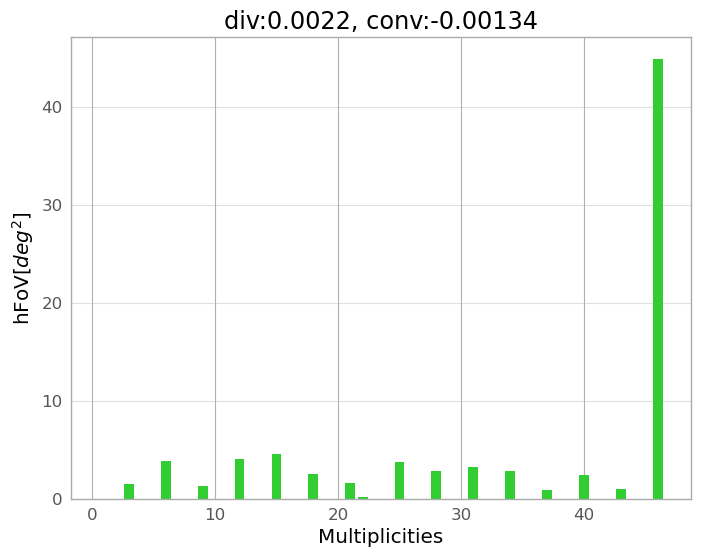

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2219402277399039 rad
-0.0 rad
1.2043925465804042 rad
-0.0479904988656012 rad
1.2046298056495823 rad
0.0479904988656012 rad
1.2042884867924208 rad
-0.0 rad
1.2384529599364629 rad
0.0532730716377664 rad
1.2379917161768568 rad
-0.0532730716377664 rad
1.2391977379163566 rad
-0.0 rad


6it [00:00,  6.79it/s]
7it [00:01,  6.77it/s]
6it [00:00,  6.82it/s]
7it [00:01,  6.45it/s]
6it [00:01,  5.29it/s]
7it [00:01,  6.47it/s]
6it [00:00,  6.12it/s]
7it [00:01,  6.21it/s]
6it [00:00,  6.52it/s]
7it [00:01,  6.18it/s]
6it [00:00,  6.76it/s]
7it [00:01,  5.78it/s]
6it [00:00,  6.64it/s]
7it [00:01,  5.29it/s]
6it [00:00,  6.67it/s]
7it [00:01,  6.62it/s]
6it [00:00,  6.52it/s]
7it [00:01,  6.63it/s]
6it [00:00,  6.28it/s]
7it [00:01,  5.43it/s]
6it [00:00,  6.36it/s]
7it [00:01,  4.95it/s]
6it [00:01,  3.45it/s]
7it [00:01,  5.72it/s]
6it [00:01,  5.00it/s]
7it [00:01,  5.44it/s]
6it [00:00,  6.04it/s]
7it [00:01,  5.70it/s]
6it [00:01,  5.92it/s]
7it [00:01,  5.74it/s]
6it [00:00,  6.04it/s]
7it [00:01,  6.50it/s]
6it [00:00,  6.61it/s]
7it [00:01,  6.59it/s]
6it [00:00,  6.70it/s]
7it [00:01,  6.79it/s]
6it [00:00,  6.54it/s]
7it [00:01,  6.80it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.79it/s]
6it [00:00,  6.90it/s]
7it [00:01,  6.74it/s]
6it [00:00,  6.13it/s]
7it [00:01,

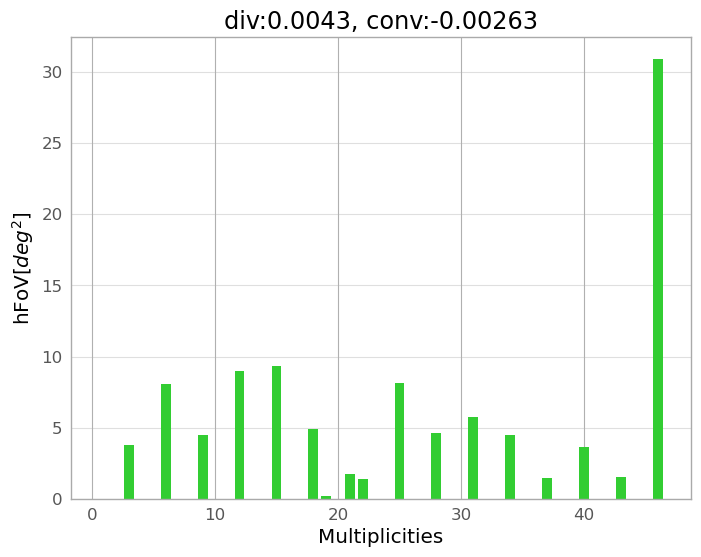

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.222120825704168 rad
-0.0 rad
1.189082111560649 rad
-0.08547884876417715 rad
1.1895383811626927 rad
0.08547884876417715 rad
1.1894492050480268 rad
-0.0 rad
1.2521943898540595 rad
0.10376783219523598 rad
1.2513663579851608 rad
-0.10376783219523598 rad
1.2543966727348794 rad
-0.0 rad


6it [00:00,  6.88it/s]
7it [00:01,  6.70it/s]
6it [00:00,  6.57it/s]
7it [00:01,  6.68it/s]
6it [00:00,  6.68it/s]
7it [00:01,  6.63it/s]
6it [00:00,  6.74it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.67it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.85it/s]
7it [00:01,  6.90it/s]
6it [00:00,  6.74it/s]
7it [00:01,  6.88it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.52it/s]
6it [00:00,  6.30it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.81it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.77it/s]
7it [00:01,  6.77it/s]
6it [00:00,  6.65it/s]
7it [00:01,  6.78it/s]
6it [00:00,  6.84it/s]
7it [00:01,  6.95it/s]
6it [00:00,  7.01it/s]
7it [00:01,  6.88it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.67it/s]
6it [00:00,  6.57it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.89it/s]
6it [00:00,  6.97it/s]
7it [00:01,  6.97it/s]
6it [00:00,  6.96it/s]
7it [00:01,  6.98it/s]
6it [00:00,  6.75it/s]
7it [00:01,  6.27it/s]
6it [00:00,  6.76it/s]
7it [00:01,  6.18it/s]
6it [00:00,  6.48it/s]
7it [00:01,

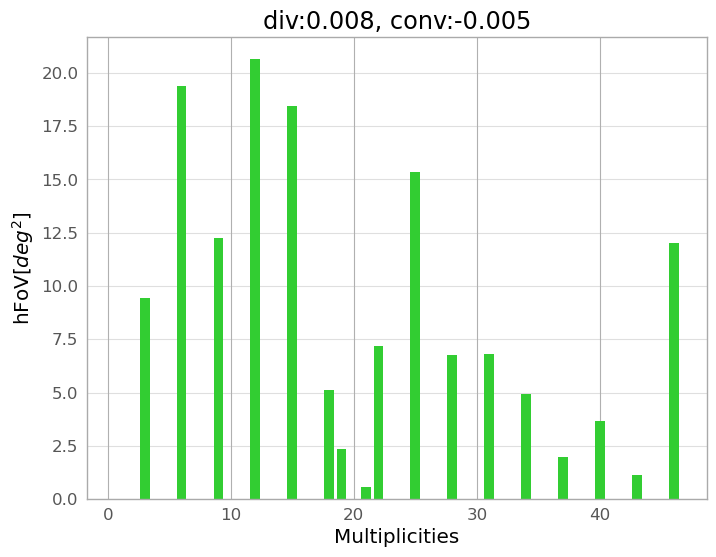

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2222844378552749 rad
-0.0 rad
1.174982099700631 rad
-0.11668434568238038 rad
1.175648326770499 rad
0.11668434568238038 rad
1.1761514501071109 rad
-0.0 rad
1.2640084898923605 rad
0.15350516525433922 rad
1.2628711151349332 rad
-0.15350516525433922 rad
1.268289130738942 rad
-0.0 rad


6it [00:00,  6.43it/s]
7it [00:01,  6.73it/s]
6it [00:00,  6.83it/s]
7it [00:01,  6.75it/s]
6it [00:00,  6.83it/s]
7it [00:01,  6.77it/s]
6it [00:00,  6.72it/s]
7it [00:01,  6.14it/s]
6it [00:00,  6.51it/s]
7it [00:01,  6.85it/s]
6it [00:00,  6.80it/s]
7it [00:01,  6.92it/s]
6it [00:00,  6.86it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.61it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.26it/s]
7it [00:01,  6.71it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.79it/s]
7it [00:01,  6.83it/s]
6it [00:00,  6.83it/s]
7it [00:01,  6.90it/s]
6it [00:00,  6.93it/s]
7it [00:01,  6.46it/s]
6it [00:00,  6.78it/s]
7it [00:00,  7.02it/s]
6it [00:00,  6.92it/s]
7it [00:01,  6.69it/s]
6it [00:00,  6.96it/s]
7it [00:01,  6.76it/s]
6it [00:00,  6.89it/s]
7it [00:01,  6.96it/s]
6it [00:00,  6.42it/s]
7it [00:01,  6.67it/s]
6it [00:00,  6.77it/s]
7it [00:00,  7.06it/s]
6it [00:00,  6.60it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.94it/s]
7it [00:01,  6.88it/s]
6it [00:00,  6.84it/s]
7it [00:01,

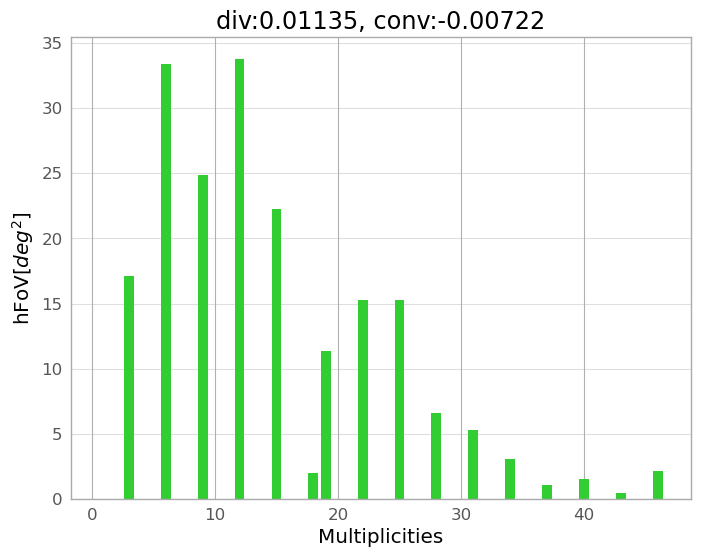

The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations[-0.67307692  0.         27.68615385]
The barycenter -0.6730769230769493
The barycenter 0.0
The barycenter 27.686153846153847
the barycenter for the calculations of the second divergence[-0.67307692  0.         27.68615385]
1.2223650588765775 rad
-0.0 rad
1.1679719740259311 rad
-0.1311735431249487 rad
1.1687455961982909 rad
0.1311735431249487 rad
1.169650686662978 rad
-0.0 rad
1.2695757146601427 rad
0.1794797475927617 rad
1.268293421520115 rad
-0.1794797475927617 rad
1.2751765105195842 rad
-0.0 rad


6it [00:00,  6.60it/s]
7it [00:01,  6.79it/s]
6it [00:00,  6.82it/s]
7it [00:01,  6.99it/s]
6it [00:01,  5.84it/s]
7it [00:01,  6.66it/s]
6it [00:00,  6.97it/s]
7it [00:01,  6.83it/s]
6it [00:00,  6.82it/s]
7it [00:01,  6.62it/s]
6it [00:00,  6.68it/s]
7it [00:01,  6.81it/s]
6it [00:00,  6.91it/s]
7it [00:01,  5.86it/s]
6it [00:00,  6.16it/s]
7it [00:01,  6.90it/s]
6it [00:00,  6.78it/s]
7it [00:01,  6.91it/s]
6it [00:00,  6.81it/s]
7it [00:00,  7.04it/s]
6it [00:00,  6.73it/s]
7it [00:01,  6.99it/s]
6it [00:00,  6.70it/s]
7it [00:01,  6.78it/s]
6it [00:00,  6.81it/s]
7it [00:01,  6.80it/s]
6it [00:00,  6.06it/s]
7it [00:01,  6.63it/s]
6it [00:01,  5.76it/s]
7it [00:03,  2.25it/s]
6it [00:03,  1.98it/s]
7it [00:01,  4.34it/s]
6it [00:01,  4.11it/s]
7it [00:01,  6.17it/s]
6it [00:00,  6.46it/s]
7it [00:01,  6.41it/s]
6it [00:00,  6.16it/s]
7it [00:01,  6.42it/s]
6it [00:00,  6.66it/s]
7it [00:01,  6.57it/s]
6it [00:00,  6.42it/s]
7it [00:01,  6.30it/s]
6it [00:00,  6.58it/s]
7it [00:01,

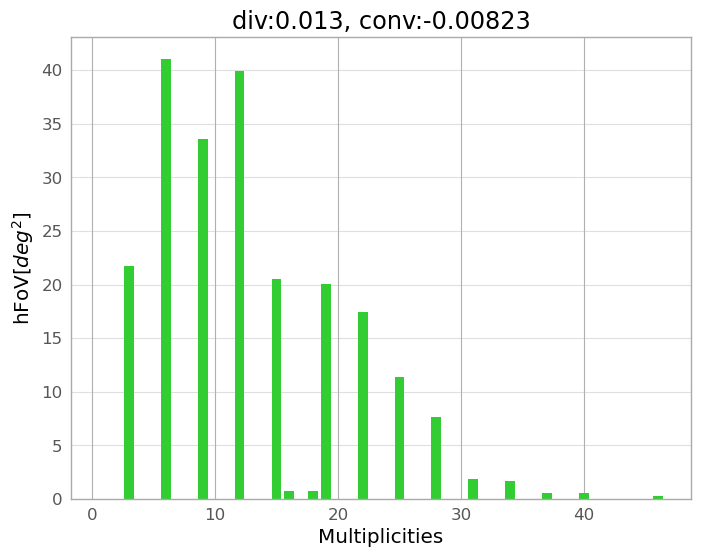

In [129]:
for i in range(5):
    hFoV_graph=[]
    multiplicities=[]
    #config_MST.divergent_pointing(div_MST[i], az=0,alt=70)
    array_conv.divergent_pointing_2_div(complete_array=complete_array,tel_group_2=array_div, div1=convergence_list[i], div2=divergence_list[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

    for j in range(46):
        hFoV_graph.append(array_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=2, array_2=array_div,subarray_mult_1=number_of_telescopes_config_SST_conv, subarray_mult_2=number_of_telescopes_config_SST_div, m_cut=j)
[0])
        multiplicities.append(j+1)
    plt.figure(figsize=(8, 6)) 
    plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
    plt.xlabel("Multiplicities")
    plt.ylabel("hFoV[$deg^2$]")
    plt.title(f"div:{divergence_list[i]}, conv:{convergence_list[i]}")
    plt.grid(axis='y', alpha=0.4)
    plt.show()   



In [130]:
hFoV_graph_full_array=[]
hFoV_graph_full_array.append(full_array.hFoV_bar_graph(multiplicity_max=46)[0])

46it [00:07,  6.45it/s]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


In [131]:
hFoV_graph_full_array

[[58.147312857286146,
  29.690012699345026,
  36.40436186103436,
  28.23436278343191,
  29.860494221028542,
  20.379098822783643,
  25.336176914812096,
  13.37624247055297,
  22.24128159809592,
  17.074380094764674,
  25.270607098779976,
  26.25415433926181,
  27.762260108000625,
  20.48401052843504,
  16.91701253628758,
  5.271813208982642,
  0.8917494980368648,
  0.013113963206424481,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0]]